In [1]:
import pandas as pd
from functools import reduce
pd.set_option('display.max_columns', None)
import gc
import os
import importlib
from importlib import reload
from tqdm.auto import tqdm
from collections import defaultdict

import ast
import seaborn as sns
import numpy as np
import os
import sys
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pathlib import Path
from PIL import Image
import hashlib
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.metrics import roc_auc_score


os.chdir('..') # 상위 경로 이동
print("현재 경로:", os.getcwd())
root_dir = '/home/DAHS1/gangmin/my_research/'
new_dir_path = "/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/"

현재 경로: /home/DAHS1/gangmin/my_research/clinical_multimodal_learning


In [2]:
sequential_df_fluid = pd.read_feather(new_dir_path + "sequential_df_fluid.ftr")
sequential_df_output = pd.read_feather(new_dir_path + "sequential_df_output.ftr")
imputed_df_chart = pd.read_feather(new_dir_path + "imputed_df_chart.ftr")
imputed_df_bp = pd.read_feather(new_dir_path + "imputed_bp_df.ftr")

cached_cxr_df = pd.read_feather(new_dir_path + "cached_final_cxr_df_in_icu_20260526.ftr")

In [3]:
imputed_df_chart['itemid'].nunique()

16

In [4]:
# imputed_cxr_df['Edema'].value_counts()

---

In [5]:
imputed_df_chart.columns

Index(['stay_id', 'itemid', 'slot_idx', 'slot_start', 'value'], dtype='object')

In [6]:
df_pivot_value = imputed_df_chart.pivot_table(
    index=['stay_id', 'slot_idx'],
    columns='itemid',
    values=['value']
).reset_index()

df_pivot_value.columns = [
    str(col[1]) if col[0] == 'value' else f'{col[0]}_{str(col[1])}'
    for col in df_pivot_value.columns.values
]

In [7]:
df_pivot_value

,stay_id_,slot_idx_,220045,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456
0,30000646,0,101.0,30.5,97.5,8.3,1.0,137.0,36.888889,40.0,11.0,1.4,12.0,0.05,4.0,4.0,3972.0,3.0
1,30000646,1,101.0,30.5,97.5,8.5,0.9,138.0,36.888889,40.0,12.0,1.4,12.0,0.05,3.5,4.0,3972.0,3.0
2,30000646,2,97.0,19.0,94.0,8.5,0.9,138.0,36.888889,40.0,12.0,1.4,12.0,0.05,3.5,4.0,3972.0,3.0
3,30000646,3,97.0,19.0,94.0,8.5,0.9,138.0,36.888889,40.0,12.0,1.4,12.0,0.05,3.5,4.0,3972.0,3.0
4,30000646,4,93.0,18.0,98.0,8.5,0.9,138.0,36.888889,40.0,12.0,1.4,12.0,0.05,3.5,4.0,3972.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2418144,39998622,427,108.0,35.0,93.0,12.4,1.0,139.0,36.944444,50.0,38.0,1.1,12.0,0.05,3.9,4.0,3972.0,2.7
2418145,39998622,428,108.0,35.0,93.0,12.4,1.0,139.0,36.944444,50.0,38.0,1.1,12.0,0.05,3.9,4.0,3972.0,2.7
2418146,39998622,429,106.0,35.0,93.0,12.4,1.0,139.0,36.944444,50.0,38.0,1.1,12.0,0.05,3.9,4.0,3972.0,2.7
2418147,39998622,430,106.0,35.0,93.0,12.4,1.0,139.0,36.944444,50.0,38.0,1.1,12.0,0.05,3.9,4.0,3972.0,2.7


In [8]:
df_pivot_value.isnull().sum()

stay_id_     0
slot_idx_    0
220045       0
220210       0
220277       0
220546       0
220615       0
220645       0
223761       0
223835       0
225624       0
225668       0
227073       0
227429       0
227442       0
227445       0
227446       0
227456       0
dtype: int64

In [9]:
# FiO2
df_pivot_value['223835']

0          40.0
1          40.0
2          40.0
3          40.0
4          40.0
           ... 
2418144    50.0
2418145    50.0
2418146    50.0
2418147    50.0
2418148    50.0
Name: 223835, Length: 2418149, dtype: float64

In [10]:
df_pivot_value['223835'] = df_pivot_value['223835'] / 100
print(f"Min FiO2 Ratio: {df_pivot_value['223835'].min()}")
print(f"Max FiO2 Ratio: {df_pivot_value['223835'].max()}")

Min FiO2 Ratio: 0.21
Max FiO2 Ratio: 1.0


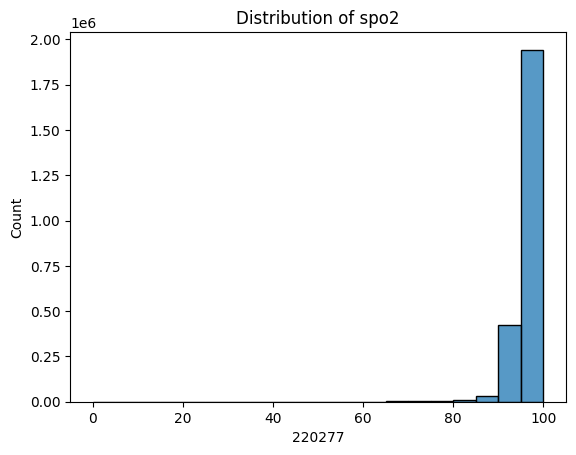

In [11]:
# spo2
sns.histplot(df_pivot_value['220277'], bins=20)
plt.title('Distribution of spo2')
plt.show()

In [12]:
def calculate_spo2_fio2(spo2, fio2):
    return spo2 / fio2

df_pivot_value['spo2_fio2'] = df_pivot_value.apply(
    lambda row: calculate_spo2_fio2(row["220277"], row['223835']), 
    axis=1
)

In [13]:
df_pivot_value['220277']

0          97.5
1          97.5
2          94.0
3          94.0
4          98.0
           ... 
2418144    93.0
2418145    93.0
2418146    93.0
2418147    93.0
2418148    93.0
Name: 220277, Length: 2418149, dtype: float64

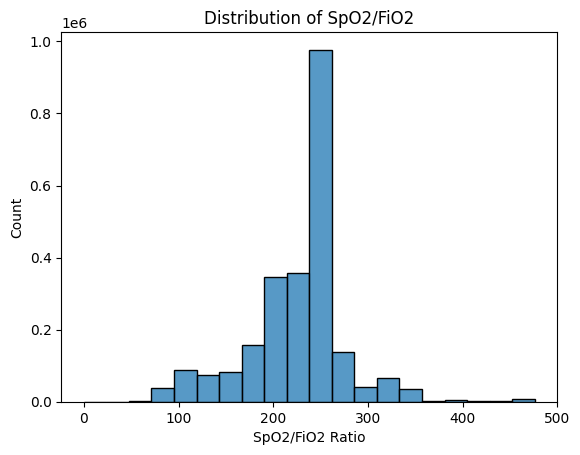

In [14]:
sns.histplot(df_pivot_value['spo2_fio2'], bins=20)
plt.title('Distribution of SpO2/FiO2')
plt.xlabel('SpO2/FiO2 Ratio')
plt.show()

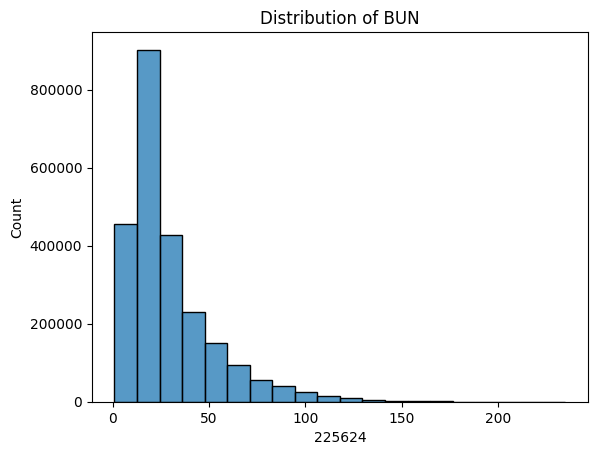

In [15]:
sns.histplot(df_pivot_value['225624'], bins=20)
plt.title('Distribution of BUN')
plt.show()

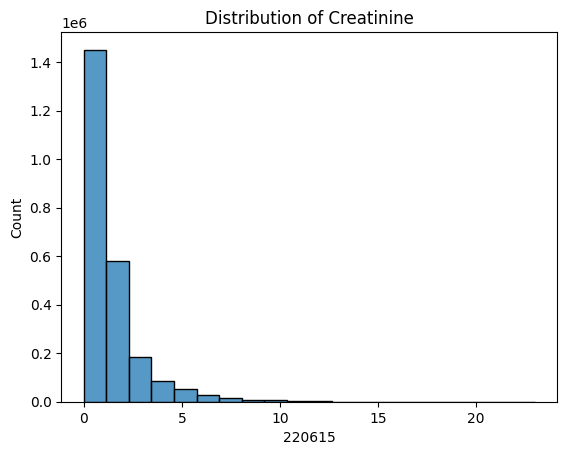

In [16]:
sns.histplot(df_pivot_value['220615'], bins=20)
plt.title('Distribution of Creatinine')
plt.show()

In [17]:
df_pivoted_chart = df_pivot_value.copy()
df_pivoted_chart

,stay_id_,slot_idx_,220045,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2
0,30000646,0,101.0,30.5,97.5,8.3,1.0,137.0,36.888889,0.4,11.0,1.4,12.0,0.05,4.0,4.0,3972.0,3.0,243.75
1,30000646,1,101.0,30.5,97.5,8.5,0.9,138.0,36.888889,0.4,12.0,1.4,12.0,0.05,3.5,4.0,3972.0,3.0,243.75
2,30000646,2,97.0,19.0,94.0,8.5,0.9,138.0,36.888889,0.4,12.0,1.4,12.0,0.05,3.5,4.0,3972.0,3.0,235.00
3,30000646,3,97.0,19.0,94.0,8.5,0.9,138.0,36.888889,0.4,12.0,1.4,12.0,0.05,3.5,4.0,3972.0,3.0,235.00
4,30000646,4,93.0,18.0,98.0,8.5,0.9,138.0,36.888889,0.4,12.0,1.4,12.0,0.05,3.5,4.0,3972.0,3.0,245.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2418144,39998622,427,108.0,35.0,93.0,12.4,1.0,139.0,36.944444,0.5,38.0,1.1,12.0,0.05,3.9,4.0,3972.0,2.7,186.00
2418145,39998622,428,108.0,35.0,93.0,12.4,1.0,139.0,36.944444,0.5,38.0,1.1,12.0,0.05,3.9,4.0,3972.0,2.7,186.00
2418146,39998622,429,106.0,35.0,93.0,12.4,1.0,139.0,36.944444,0.5,38.0,1.1,12.0,0.05,3.9,4.0,3972.0,2.7,186.00
2418147,39998622,430,106.0,35.0,93.0,12.4,1.0,139.0,36.944444,0.5,38.0,1.1,12.0,0.05,3.9,4.0,3972.0,2.7,186.00


In [18]:
# # input
# df_pivot_input = sequential_df_med.pivot_table(
#     index=['stay_id', 'hour_slot'],
#     columns='itemid',                
#     values=['input_amount']
# ).reset_index()

# df_pivot_input.columns = [
#     str(col[1]) if col[0] == 'input_amount' else f'{col[0]}_{str(col[1])}'
#     for col in df_pivot_input.columns.values
# ]

# df_pivot_input

In [19]:
# print(sequential_df_proc['stay_id'].nunique())
# print(sequential_df_proc['hadm_id'].nunique())

In [20]:
# hadm_df = sequential_df_proc[['hadm_id', 'stay_id']].drop_duplicates().reset_index(drop=True)
# hadm_df

In [21]:
# # procedure
# df_pivot_proc = sequential_df_proc.pivot_table(
#     index=['stay_id', 'hour_slot'],
#     columns='itemid',                
#     values=['procedure_flag']
# ).reset_index()

# df_pivot_proc.columns = [
#     str(col[1]) if col[0] == 'procedure_flag' else f'{col[0]}_{str(col[1])}'
#     for col in df_pivot_proc.columns.values
# ]

# df_pivot_proc

In [22]:
sequential_df_output

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end,urine_output
0,12207593,22795209,30000646,0,2194-04-29 01:39:22,2194-04-29 02:09:22,66.744359
1,12207593,22795209,30000646,1,2194-04-29 02:09:22,2194-04-29 02:39:22,66.744359
2,12207593,22795209,30000646,2,2194-04-29 02:39:22,2194-04-29 03:09:22,66.744359
3,12207593,22795209,30000646,3,2194-04-29 03:09:22,2194-04-29 03:39:22,66.744359
4,12207593,22795209,30000646,4,2194-04-29 03:39:22,2194-04-29 04:09:22,66.744359
...,...,...,...,...,...,...,...
2418144,19046950,24352151,39998622,427,2135-02-20 15:43:55,2135-02-20 16:13:55,168.796763
2418145,19046950,24352151,39998622,428,2135-02-20 16:13:55,2135-02-20 16:43:55,114.406780
2418146,19046950,24352151,39998622,429,2135-02-20 16:43:55,2135-02-20 17:13:55,61.334746
2418147,19046950,24352151,39998622,430,2135-02-20 17:13:55,2135-02-20 17:43:55,0.000000


In [23]:
sequential_df_output = sequential_df_output[['stay_id', 'slot_idx', 'urine_output']]
sequential_df_output = sequential_df_output.rename(columns={'urine_output': 'urine'})
sequential_df_output = sequential_df_output.sort_values(['stay_id', 'slot_idx']).reset_index(drop=True)

In [24]:
sequential_df_output

,stay_id,slot_idx,urine
0,30000646,0,66.744359
1,30000646,1,66.744359
2,30000646,2,66.744359
3,30000646,3,66.744359
4,30000646,4,66.744359
...,...,...,...
2418144,39998622,427,168.796763
2418145,39998622,428,114.406780
2418146,39998622,429,61.334746
2418147,39998622,430,0.000000


In [25]:
sequential_df_fluid

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end,fluid_category,input_amount
0,10001884,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 04:50:05,fluid_alb,0.0
1,10001884,26184834,37510196,1,2131-01-11 04:50:05,2131-01-11 05:20:05,fluid_alb,0.0
2,10001884,26184834,37510196,2,2131-01-11 05:20:05,2131-01-11 05:50:05,fluid_alb,0.0
3,10001884,26184834,37510196,3,2131-01-11 05:50:05,2131-01-11 06:20:05,fluid_alb,0.0
4,10001884,26184834,37510196,4,2131-01-11 06:20:05,2131-01-11 06:50:05,fluid_alb,0.0
...,...,...,...,...,...,...,...,...
4836293,19999987,23865745,36195440,89,2145-11-04 19:29:00,2145-11-04 19:59:00,fluid_cyst,0.0
4836294,19999987,23865745,36195440,90,2145-11-04 19:59:00,2145-11-04 20:29:00,fluid_cyst,0.0
4836295,19999987,23865745,36195440,91,2145-11-04 20:29:00,2145-11-04 20:59:00,fluid_cyst,201.2
4836296,19999987,23865745,36195440,92,2145-11-04 20:59:00,2145-11-04 21:29:00,fluid_cyst,0.0


In [26]:
# fluid
df_pivot_fluid = sequential_df_fluid.pivot_table(
    index=['stay_id', 'slot_idx'],
    columns='fluid_category',                
    values=['input_amount']
).reset_index()

df_pivot_fluid.columns = [
    str(col[1]) if col[0] == 'input_amount' else f'{col[0]}_{str(col[1])}'
    for col in df_pivot_fluid.columns.values
]

df_pivot_fluid = df_pivot_fluid.drop(columns=['fluid_alb'])

df_pivot_fluid

,stay_id_,slot_idx_,fluid_cyst
0,30000646,0,318.114036
1,30000646,1,2.500253
2,30000646,2,2.500253
3,30000646,3,2.500253
4,30000646,4,2.500253
...,...,...,...
2418144,39998622,427,2.500000
2418145,39998622,428,2.500000
2418146,39998622,429,2.500000
2418147,39998622,430,2.500000


In [27]:
imputed_df_bp

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end,sbp,dbp
0,12207593,22795209,30000646,0,2194-04-29 01:39:22,2194-04-29 02:09:22,109.0,65.5
1,12207593,22795209,30000646,1,2194-04-29 02:09:22,2194-04-29 02:39:22,109.0,65.5
2,12207593,22795209,30000646,2,2194-04-29 02:39:22,2194-04-29 03:09:22,97.0,58.0
3,12207593,22795209,30000646,3,2194-04-29 03:09:22,2194-04-29 03:39:22,97.0,58.0
4,12207593,22795209,30000646,4,2194-04-29 03:39:22,2194-04-29 04:09:22,98.0,57.0
...,...,...,...,...,...,...,...,...
2418144,19046950,24352151,39998622,427,2135-02-20 15:43:55,2135-02-20 16:13:55,127.0,82.0
2418145,19046950,24352151,39998622,428,2135-02-20 16:13:55,2135-02-20 16:43:55,127.0,82.0
2418146,19046950,24352151,39998622,429,2135-02-20 16:43:55,2135-02-20 17:13:55,120.0,71.0
2418147,19046950,24352151,39998622,430,2135-02-20 17:13:55,2135-02-20 17:43:55,120.0,71.0


In [28]:
# df_pivot_input = df_pivot_input.rename(columns={'stay_id_': 'stay_id', 'hour_slot_': 'hour_slot'})
# df_pivot_proc = df_pivot_proc.rename(columns={'stay_id_': 'stay_id', 'hour_slot_': 'hour_slot'})

df_pivoted_chart = df_pivoted_chart.rename(columns={'stay_id_': 'stay_id', 'slot_idx_': 'slot_idx'})
df_pivot_fluid = df_pivot_fluid.rename(columns={'stay_id_': 'stay_id', 'slot_idx_': 'slot_idx'})

def merge_all_icu_events(df_chart, df_fluid, df_pivot_bp, df_output):
    dataframes = [df_chart, df_fluid, df_pivot_bp, df_output]

    icu_events = reduce(lambda left, right: pd.merge(left, right, on=['stay_id', 'slot_idx'], how='left'), dataframes)
    icu_events.columns = icu_events.columns.map(str)
    return icu_events

df_pivot_bp = imputed_df_bp[['stay_id', 'slot_idx', 'sbp', 'dbp']]
icu_events_df = merge_all_icu_events(df_pivoted_chart, df_pivot_fluid, df_pivot_bp, sequential_df_output)

In [29]:
icu_events_df

,stay_id,slot_idx,220045,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,fluid_cyst,sbp,dbp,urine
0,30000646,0,101.0,30.5,97.5,8.3,1.0,137.0,36.888889,0.4,11.0,1.4,12.0,0.05,4.0,4.0,3972.0,3.0,243.75,318.114036,109.0,65.5,66.744359
1,30000646,1,101.0,30.5,97.5,8.5,0.9,138.0,36.888889,0.4,12.0,1.4,12.0,0.05,3.5,4.0,3972.0,3.0,243.75,2.500253,109.0,65.5,66.744359
2,30000646,2,97.0,19.0,94.0,8.5,0.9,138.0,36.888889,0.4,12.0,1.4,12.0,0.05,3.5,4.0,3972.0,3.0,235.00,2.500253,97.0,58.0,66.744359
3,30000646,3,97.0,19.0,94.0,8.5,0.9,138.0,36.888889,0.4,12.0,1.4,12.0,0.05,3.5,4.0,3972.0,3.0,235.00,2.500253,97.0,58.0,66.744359
4,30000646,4,93.0,18.0,98.0,8.5,0.9,138.0,36.888889,0.4,12.0,1.4,12.0,0.05,3.5,4.0,3972.0,3.0,245.00,2.500253,98.0,57.0,66.744359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2418144,39998622,427,108.0,35.0,93.0,12.4,1.0,139.0,36.944444,0.5,38.0,1.1,12.0,0.05,3.9,4.0,3972.0,2.7,186.00,2.500000,127.0,82.0,168.796763
2418145,39998622,428,108.0,35.0,93.0,12.4,1.0,139.0,36.944444,0.5,38.0,1.1,12.0,0.05,3.9,4.0,3972.0,2.7,186.00,2.500000,127.0,82.0,114.406780
2418146,39998622,429,106.0,35.0,93.0,12.4,1.0,139.0,36.944444,0.5,38.0,1.1,12.0,0.05,3.9,4.0,3972.0,2.7,186.00,2.500000,120.0,71.0,61.334746
2418147,39998622,430,106.0,35.0,93.0,12.4,1.0,139.0,36.944444,0.5,38.0,1.1,12.0,0.05,3.9,4.0,3972.0,2.7,186.00,2.500000,120.0,71.0,0.000000


In [30]:
key_id_icu = cached_cxr_df[['subject_id', 'hadm_id','stay_id']].drop_duplicates().reset_index(drop=True)
key_id_icu

,subject_id,hadm_id,stay_id
0,10001884,26184834,37510196
1,10002428,23473524,35479615
2,10002428,28662225,33987268
3,10002428,28662225,38875437
4,10003400,20214994,32128372
...,...,...,...
13433,19998330,24096838,33428243
13434,19998843,24842066,30988867
13435,19999287,20175828,35165301
13436,19999442,26785317,32336619


In [31]:
icu_events_df = icu_events_df.merge(key_id_icu, how='left', on='stay_id')
icu_events_df = icu_events_df.sort_values(by=['subject_id', 'hadm_id', 'stay_id', 'slot_idx']).reset_index(drop=True)
icu_events_df

,stay_id,slot_idx,220045,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,fluid_cyst,sbp,dbp,urine,subject_id,hadm_id
0,37510196,0,38.0,20.0,97.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,242.500000,56.268077,180.0,12.0,29.473057,10001884,26184834
1,37510196,1,60.0,10.0,98.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,245.000000,68.706707,167.0,49.0,29.473057,10001884,26184834
2,37510196,2,60.0,10.0,98.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,245.000000,15.910061,167.0,49.0,29.473057,10001884,26184834
3,37510196,3,72.0,20.0,100.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,250.000000,15.910061,102.0,63.0,29.473057,10001884,26184834
4,37510196,4,71.0,17.5,90.0,18.4,1.1,135.5,35.400000,0.40,30.0,1.5,11.0,0.08,3.975,14.0,3972.0,3.5,225.000000,16.992743,110.0,76.0,29.473057,10001884,26184834
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2418144,36195440,89,93.0,20.0,100.0,11.6,1.2,147.0,37.000000,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,285.714286,0.000000,163.0,120.0,14.728097,19999987,23865745
2418145,36195440,90,92.0,23.0,100.0,11.6,1.2,147.0,37.833333,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,285.714286,0.000000,163.0,120.0,1.963746,19999987,23865745
2418146,36195440,91,92.0,23.0,100.0,11.6,1.2,147.0,37.833333,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,285.714286,201.200000,163.0,120.0,0.000000,19999987,23865745
2418147,36195440,92,87.0,24.0,98.0,11.6,1.2,147.0,37.000000,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,280.000000,0.000000,143.0,107.0,0.000000,19999987,23865745


In [32]:
# 무결측 처리 완료
icu_events_df.isnull().sum()

stay_id       0
slot_idx      0
220045        0
220210        0
220277        0
220546        0
220615        0
220645        0
223761        0
223835        0
225624        0
225668        0
227073        0
227429        0
227442        0
227445        0
227446        0
227456        0
spo2_fio2     0
fluid_cyst    0
sbp           0
dbp           0
urine         0
subject_id    0
hadm_id       0
dtype: int64

In [33]:
icu_events_df.columns

Index(['stay_id', 'slot_idx', '220045', '220210', '220277', '220546', '220615',
       '220645', '223761', '223835', '225624', '225668', '227073', '227429',
       '227442', '227445', '227446', '227456', 'spo2_fio2', 'fluid_cyst',
       'sbp', 'dbp', 'urine', 'subject_id', 'hadm_id'],
      dtype='object')

In [34]:
front_cols = ['subject_id', 'hadm_id', 'stay_id', 'slot_idx']
remaining_cols = [col for col in icu_events_df.columns if col not in front_cols]

icu_events_df = icu_events_df[front_cols + remaining_cols]

In [35]:
patient_df = pd.read_parquet("/home/DAHS1/gangmin/my_research/data/mimic-iv/core/parquet/patients.parquet")
patient_df = patient_df[['subject_id', 'gender']]

df_weight = pd.read_feather('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/df_weight.ftr')
df_weight = df_weight.rename(columns={'valuenum':'weight'})
df_weight = df_weight.drop(columns=['charttime', 'stay_id', 'hadm_id'])
subject_weight = df_weight.groupby('subject_id')['weight'].mean().reset_index()

key_id_icu['subject_id'] = key_id_icu['subject_id'].astype(int)
patient_df['subject_id'] = patient_df['subject_id'].astype(int)
subject_weight['subject_id'] = subject_weight['subject_id'].astype(int)

demo_df = key_id_icu.merge(patient_df, how='left', on=['subject_id'])
demo_df = demo_df.merge(subject_weight, how='left', on=['subject_id'])
demo_df

,subject_id,hadm_id,stay_id,gender,weight
0,10001884,26184834,37510196,F,65.000000
1,10002428,23473524,35479615,F,46.329558
2,10002428,28662225,33987268,F,46.329558
3,10002428,28662225,38875437,F,46.329558
4,10003400,20214994,32128372,F,95.526079
...,...,...,...,...,...
13433,19998330,24096838,33428243,F,78.670588
13434,19998843,24842066,30988867,M,72.891566
13435,19999287,20175828,35165301,F,86.850725
13436,19999442,26785317,32336619,M,107.392908


In [36]:
# 8개의 subject_id만 weight가 결측임. 
demo_df['weight'].isnull().sum()

# 따라서 그냥 성별별 median 값으로 채우는 것을 선택함.
gender_median = demo_df.groupby('gender')['weight'].median()

# M, F만 확실하다면 get() 없이 바로 접근
print(f"남성 체중 중앙값: {gender_median['M']}")
print(f"여성 체중 중앙값: {gender_median['F']}")

# 결측치 채우기
demo_df['weight'] = demo_df['weight'].fillna(demo_df['gender'].map(gender_median))

icu_events_df = icu_events_df.merge(demo_df[['stay_id', 'weight']], how='left', on=['stay_id'])

# Crystalloid / Patient weight
icu_events_df['cryst_weight'] = icu_events_df['fluid_cyst'] / icu_events_df['weight']

icu_events_df = icu_events_df.drop(columns=['weight', 'fluid_cyst'])

남성 체중 중앙값: 83.06099597585514
여성 체중 중앙값: 70.35015723270439


In [37]:
stay_lens = icu_events_df.groupby('stay_id').size()
print("stays with T<8:", (stay_lens < 8).sum())
print("min T:", stay_lens.min(), " | distribution:")
print(stay_lens.describe(percentiles=[.01, .05, .1, .5, .9]))

stays with T<8: 3
min T: 5  | distribution:
count    13438.000000
mean       179.948579
std        147.310140
min          5.000000
1%          23.000000
5%          38.000000
10%         48.000000
50%        133.000000
90%        396.000000
max        726.000000
dtype: float64


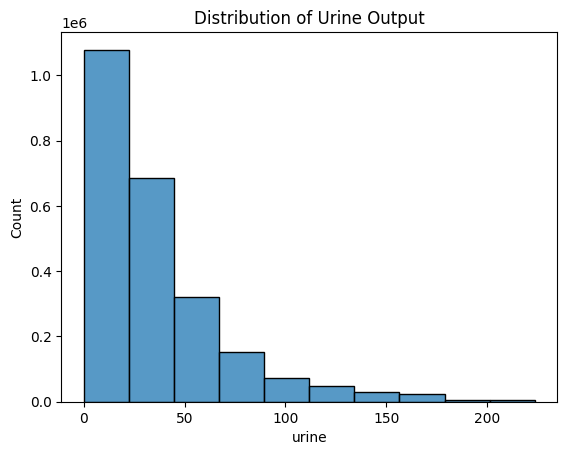

In [38]:
sns.histplot(icu_events_df['urine'], bins=10)
plt.title('Distribution of Urine Output')
plt.show()

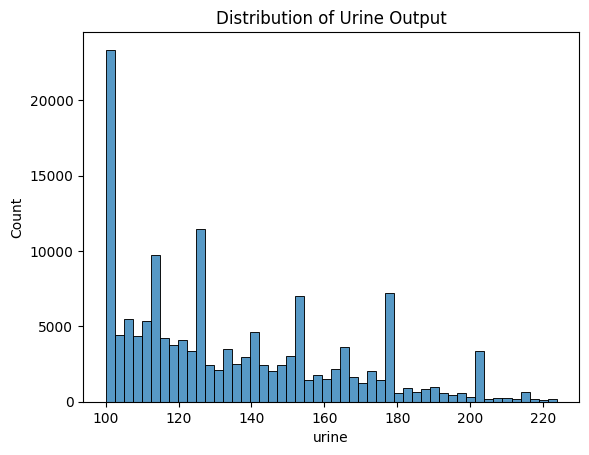

In [39]:
urine_upper_outlier_df = icu_events_df[icu_events_df['urine'] > 100]

sns.histplot(urine_upper_outlier_df['urine'], bins=50)
plt.title('Distribution of Urine Output')
plt.show()

In [40]:
print(icu_events_df['urine'].quantile(0.99))
print(icu_events_df['urine'].max())
print(icu_events_df['urine'].min())
print(icu_events_df['urine'].mean())

167.67125312012888
223.72881355932202
0.0
35.05670175735119


In [41]:
icu_events_df.to_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/icu_events_df_20260610.ftr")

In [42]:
# CXR_LABEL_COLS = [
#     'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 
#     'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices'
# ]

CXR_LABEL_COLS = [
    'Edema', 'Cardiomegaly', 'Pneumonia', 'Consolidation'
]

# chexpert U-Ones (Uncertain to Positive)
# imputed_cxr_df.loc[:, CXR_LABEL_COLS] = imputed_cxr_df[CXR_LABEL_COLS].fillna(0)
# imputed_cxr_df.loc[:, CXR_LABEL_COLS] = imputed_cxr_df[CXR_LABEL_COLS].replace(-1, 1)

# chexpert U-Zeros (Uncertain to Negative)
# imputed_cxr_df.loc[:, CXR_LABEL_COLS] = imputed_cxr_df[CXR_LABEL_COLS].replace(-1, 0)

- 이제 imputed_cxr_df를 cached_cxr_df로 대체함.

- icd past history 반영하면 더 좋을 듯 (CPE에 심부전이라던지)

In [43]:
icu_events_df

,subject_id,hadm_id,stay_id,slot_idx,220045,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,sbp,dbp,urine,cryst_weight
0,10001884,26184834,37510196,0,38.0,20.0,97.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,242.500000,180.0,12.0,29.473057,0.865663
1,10001884,26184834,37510196,1,60.0,10.0,98.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,245.000000,167.0,49.0,29.473057,1.057026
2,10001884,26184834,37510196,2,60.0,10.0,98.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,245.000000,167.0,49.0,29.473057,0.244770
3,10001884,26184834,37510196,3,72.0,20.0,100.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,250.000000,102.0,63.0,29.473057,0.244770
4,10001884,26184834,37510196,4,71.0,17.5,90.0,18.4,1.1,135.5,35.400000,0.40,30.0,1.5,11.0,0.08,3.975,14.0,3972.0,3.5,225.000000,110.0,76.0,29.473057,0.261427
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2418144,19999987,23865745,36195440,89,93.0,20.0,100.0,11.6,1.2,147.0,37.000000,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,285.714286,163.0,120.0,14.728097,0.000000
2418145,19999987,23865745,36195440,90,92.0,23.0,100.0,11.6,1.2,147.0,37.833333,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,285.714286,163.0,120.0,1.963746,0.000000
2418146,19999987,23865745,36195440,91,92.0,23.0,100.0,11.6,1.2,147.0,37.833333,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,285.714286,163.0,120.0,0.000000,2.668127
2418147,19999987,23865745,36195440,92,87.0,24.0,98.0,11.6,1.2,147.0,37.000000,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,280.000000,143.0,107.0,0.000000,0.000000


In [44]:
cached_cxr_df = cached_cxr_df[['subject_id', 'hadm_id', 'stay_id', 'slot_idx', 'intime', 'outtime', 'cxr_flag', 'Consolidation', 'Pneumonia', 'Cardiomegaly', 'Edema', 'report', 'txt_path', 'raddino_emb_path', 'hybrid_emb_path']]

In [45]:
df_admission = pd.read_parquet("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/core_parquet/admissions.parquet")
df_admission.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,None,URGENT,P874LG,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,None,EW EMER.,P09Q6Y,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,None,EW EMER.,P60CC5,EMERGENCY ROOM,HOSPICE,Medicaid,ENGLISH,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,None,EW EMER.,P30KEH,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,None,EU OBSERVATION,P51VDL,EMERGENCY ROOM,None,Other,ENGLISH,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0


In [46]:
df_death_time = df_admission[['hadm_id', 'admittime', 'dischtime', 'deathtime']]

df_icu_subset = cached_cxr_df[['hadm_id', 'stay_id', 'intime', 'outtime']].drop_duplicates()

df_admission['hospital_expire_flag'] = df_admission['deathtime'].notna().astype(int) # deathtime이 있으면 1, 없으면 0

df_merged = pd.merge(df_icu_subset, 
    df_admission[['hadm_id', 'dischtime', 'deathtime', 'hospital_expire_flag']], 
    on='hadm_id', how='left'
)

In [47]:
time_cols = ['intime', 'outtime', 'dischtime', 'deathtime']
for col in time_cols:
    df_merged[col] = pd.to_datetime(df_merged[col])

# 이번 Stay가 사망과 직결되었는지 판별하는 'stay_expire_flag' 생성
# 조건 1: 병원 내 사망 기록이 있어야 함
# 조건 2: 사망 시점이 ICU 입실 이후여야 함
# 조건 3: 사망 시점이 ICU 퇴실 후 24시간 이내이거나 퇴실 전이어야 함
def check_stay_mortality(row, buffer_hours=24):
    if pd.isna(row['deathtime']):
        return 0 # 살아서 퇴원한 경우 (deathtime 컬럼이 비어있음)
    
    # ICU 입실 이후 사망했고, 퇴실 시점으로부터 24시간 이내에 사망한 경우 1 부여
    if (row['deathtime'] >= row['intime']) and \
        (row['deathtime'] <= (row['outtime'] + pd.Timedelta(hours=buffer_hours))):
        return 1
    return 0

df_merged['stay_expire_flag'] = df_merged.apply(check_stay_mortality, axis=1)

cached_cxr_df = pd.merge(
    cached_cxr_df, 
    df_merged[['stay_id', 'stay_expire_flag']], 
    on='stay_id', 
    how='left'
)

# 결측치는 생존(0)으로 채움
cached_cxr_df['stay_expire_flag'] = cached_cxr_df['stay_expire_flag'].fillna(0).astype(int)

In [48]:
ts_dataset = icu_events_df.merge(cached_cxr_df, how='left', on=['subject_id', 'hadm_id', 'stay_id', 'slot_idx'])
ts_dataset

,subject_id,hadm_id,stay_id,slot_idx,220045,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,sbp,dbp,urine,cryst_weight,intime,outtime,cxr_flag,Consolidation,Pneumonia,Cardiomegaly,Edema,report,txt_path,raddino_emb_path,hybrid_emb_path,stay_expire_flag
0,10001884,26184834,37510196,0,38.0,20.0,97.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,242.500000,180.0,12.0,29.473057,0.865663,2131-01-11 04:20:05,2131-01-20 08:27:30,1,0.0,0.0,0.0,1.0,"In comparison to ___ chest radiograph, pulmona...",/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1
1,10001884,26184834,37510196,1,60.0,10.0,98.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,245.000000,167.0,49.0,29.473057,1.057026,2131-01-11 04:20:05,2131-01-20 08:27:30,0,NaN,NaN,NaN,NaN,None,None,None,None,1
2,10001884,26184834,37510196,2,60.0,10.0,98.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,245.000000,167.0,49.0,29.473057,0.244770,2131-01-11 04:20:05,2131-01-20 08:27:30,0,NaN,NaN,NaN,NaN,None,None,None,None,1
3,10001884,26184834,37510196,3,72.0,20.0,100.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,250.000000,102.0,63.0,29.473057,0.244770,2131-01-11 04:20:05,2131-01-20 08:27:30,0,NaN,NaN,NaN,NaN,None,None,None,None,1
4,10001884,26184834,37510196,4,71.0,17.5,90.0,18.4,1.1,135.5,35.400000,0.40,30.0,1.5,11.0,0.08,3.975,14.0,3972.0,3.5,225.000000,110.0,76.0,29.473057,0.261427,2131-01-11 04:20:05,2131-01-20 08:27:30,0,NaN,NaN,NaN,NaN,None,None,None,None,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2418144,19999987,23865745,36195440,89,93.0,20.0,100.0,11.6,1.2,147.0,37.000000,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,285.714286,163.0,120.0,14.728097,0.000000,2145-11-02 22:59:00,2145-11-04 21:29:30,0,NaN,NaN,NaN,NaN,None,None,None,None,0
2418145,19999987,23865745,36195440,90,92.0,23.0,100.0,11.6,1.2,147.0,37.833333,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,285.714286,163.0,120.0,1.963746,0.000000,2145-11-02 22:59:00,2145-11-04 21:29:30,0,NaN,NaN,NaN,NaN,None,None,None,None,0
2418146,19999987,23865745,36195440,91,92.0,23.0,100.0,11.6,1.2,147.0,37.833333,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,285.714286,163.0,120.0,0.000000,2.668127,2145-11-02 22:59:00,2145-11-04 21:29:30,0,NaN,NaN,NaN,NaN,None,None,None,None,0
2418147,19999987,23865745,36195440,92,87.0,24.0,98.0,11.6,1.2,147.0,37.000000,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,280.000000,143.0,107.0,0.000000,0.000000,2145-11-02 22:59:00,2145-11-04 21:29:30,0,NaN,NaN,NaN,NaN,None,None,None,None,0


In [49]:
def decay_by_phenotype(row, fast_hl=12, slow_hl=72, default_hl=48):
    # 1. Fast Decay (CPE) 조건: 심비대증 또는 심부전 마커
    is_fast = (row.get('Cardiomegaly', 0) == 1) or \
            (pd.notna(row.get('bnp')) and row.get('bnp') >= 500)
            # 향후 ICD code 이력 추가

    # 2. Slow Decay (NCPE) 조건: 폐렴, 경화, 또는 S/F ratio 235 이하
    is_slow = (row.get('Pneumonia', 0) == 1) or \
            (row.get('Consolidation', 0) == 1) or \
            (pd.notna(row.get('spo2_fio2')) and row.get('spo2_fio2') <= 235)

    if is_fast and not is_slow:
        return fast_hl
    elif is_slow and not is_fast:
        return slow_hl
    else:
        return default_hl # Default


def apply_dynamic_soft_labeling(df, target_col='Edema', identifier='stay_id', expire_col='stay_expire_flag'):
    processed_list = []
    
    for stay_id, group in df.groupby(identifier):
        # hour_slot -> slot_idx로 변경
        group = group.sort_values('slot_idx').reset_index(drop=True)
        soft_label_col = f'{target_col}_soft'
        group[soft_label_col] = np.nan

        is_expired = group[expire_col].iloc[0] == 1 if expire_col in group.columns else False
        
        cxr_events = group[(group['cxr_flag'] == 1) & (group[target_col].notna())]
        event_indices = cxr_events.index.tolist()
        
        if not event_indices:
            processed_list.append(group)
            continue
            
        for i in range(len(event_indices)):
            idx_curr = event_indices[i]
            t_curr = group.at[idx_curr, 'slot_idx']
            val_curr = group.at[idx_curr, target_col]
            hl_curr = decay_by_phenotype(group.loc[idx_curr])
            
            group.at[idx_curr, soft_label_col] = float(val_curr)
            
            # [1] 첫 번째 촬영 이전 (Backward Fill)
            if i == 0:
                for back_idx in range(0, idx_curr):
                    # 중요: (t_curr - 현재슬롯) * 0.5를 해야 '시간'이 됩니다. (12시간 기준 유지)
                    if (t_curr - group.at[back_idx, 'slot_idx']) * 0.5 <= 12:
                        group.at[back_idx, soft_label_col] = float(val_curr)
            
            # [2] 다음 촬영이 있는 경우
            if i < len(event_indices) - 1:
                idx_next = event_indices[i+1]
                t_next = group.at[idx_next, 'slot_idx']
                val_next = group.at[idx_next, target_col]
                
                # 차이에 0.5를 곱해 실제 '시간' 단위(Hours)로 변환
                delta_t_total = (t_next - t_curr) * 0.5
                
                for j in range(idx_curr + 1, idx_next):
                    t = group.at[j, 'slot_idx']
                    delta_t = (t - t_curr) * 0.5 # 시간 단위로 변환
                    
                    if val_curr == 1 and val_next == 1:
                        group.at[j, soft_label_col] = 1.0 
                    
                    elif val_curr == 0 and val_next == 0:
                        group.at[j, soft_label_col] = 0.0 
                    
                    # 상태 호전 (반감기 감쇠)
                    elif val_curr == 1 and val_next == 0:
                        decay_val = np.exp(-np.log(2) * (delta_t / hl_curr))
                        decay_min = np.exp(-np.log(2) * (delta_t_total / hl_curr))
                        
                        if 1.0 - decay_min < 1e-5:
                            # delta_t / delta_t_total 비율은 슬롯 단위나 시간 단위나 같으므로 유지
                            scaled_decay = 1.0 - (delta_t / delta_t_total) 
                        else:
                            scaled_decay = (decay_val - decay_min) / (1.0 - decay_min)
                            
                        group.at[j, soft_label_col] = scaled_decay
                    
                    # 상태 악화 (시그모이드)
                    elif val_curr == 0 and val_next == 1:
                        progress = delta_t / delta_t_total
                        k = 10.0 
                        
                        def sigmoid(x_val):
                            return 1.0 / (1.0 + np.exp(-k * (x_val - 0.5)))
                        
                        sig_curr = sigmoid(progress)
                        sig_min = sigmoid(0.0)
                        sig_max = sigmoid(1.0)
                        scaled_sig = (sig_curr - sig_min) / (sig_max - sig_min)
                        
                        group.at[j, soft_label_col] = scaled_sig
            
            # [3] 마지막 촬영 이후 (Fade Out 처리)
            if i == len(event_indices) - 1:
                for forward_idx in range(idx_curr + 1, len(group)):
                    t = group.at[forward_idx, 'slot_idx']
                    delta_t = (t - t_curr) * 0.5 # 시간 단위로 변환
                    
                    if val_curr == 1:
                        if is_expired:
                            group.at[forward_idx, soft_label_col] = 1.0
                        else:
                            decay_val = np.exp(-np.log(2) * (delta_t / hl_curr))
                            group.at[forward_idx, soft_label_col] = decay_val

                    elif val_curr == 0:
                        # 정상 상태는 12시간까지만 확신 (delta_t가 시간 단위이므로 12 유지)
                        if delta_t <= 12: 
                            group.at[forward_idx, soft_label_col] = 0.0
                        else:
                            break
                            
        processed_list.append(group)

    final_df = pd.concat(processed_list)
    # 정렬 기준도 slot_idx로 변경
    final_df = final_df.sort_values([identifier, 'slot_idx']).reset_index(drop=True)
    return final_df

df_soft = apply_dynamic_soft_labeling(ts_dataset, target_col='Edema', identifier='stay_id', expire_col='stay_expire_flag')

In [50]:
labeling = df_soft[['stay_id', 'slot_idx', 'Edema', 'Edema_soft']]

In [51]:
df_soft

,subject_id,hadm_id,stay_id,slot_idx,220045,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,sbp,dbp,urine,cryst_weight,intime,outtime,cxr_flag,Consolidation,Pneumonia,Cardiomegaly,Edema,report,txt_path,raddino_emb_path,hybrid_emb_path,stay_expire_flag,Edema_soft
0,12207593,22795209,30000646,0,101.0,30.5,97.5,8.3,1.0,137.0,36.888889,0.4,11.0,1.4,12.0,0.05,4.0,4.0,3972.0,3.0,243.75,109.0,65.5,66.744359,4.180837,2194-04-29 01:39:22,2194-05-03 18:23:48,0,NaN,NaN,NaN,NaN,None,None,None,None,0,1.0
1,12207593,22795209,30000646,1,101.0,30.5,97.5,8.5,0.9,138.0,36.888889,0.4,12.0,1.4,12.0,0.05,3.5,4.0,3972.0,3.0,243.75,109.0,65.5,66.744359,0.032860,2194-04-29 01:39:22,2194-05-03 18:23:48,0,NaN,NaN,NaN,NaN,None,None,None,None,0,1.0
2,12207593,22795209,30000646,2,97.0,19.0,94.0,8.5,0.9,138.0,36.888889,0.4,12.0,1.4,12.0,0.05,3.5,4.0,3972.0,3.0,235.00,97.0,58.0,66.744359,0.032860,2194-04-29 01:39:22,2194-05-03 18:23:48,0,NaN,NaN,NaN,NaN,None,None,None,None,0,1.0
3,12207593,22795209,30000646,3,97.0,19.0,94.0,8.5,0.9,138.0,36.888889,0.4,12.0,1.4,12.0,0.05,3.5,4.0,3972.0,3.0,235.00,97.0,58.0,66.744359,0.032860,2194-04-29 01:39:22,2194-05-03 18:23:48,0,NaN,NaN,NaN,NaN,None,None,None,None,0,1.0
4,12207593,22795209,30000646,4,93.0,18.0,98.0,8.5,0.9,138.0,36.888889,0.4,12.0,1.4,12.0,0.05,3.5,4.0,3972.0,3.0,245.00,98.0,57.0,66.744359,0.032860,2194-04-29 01:39:22,2194-05-03 18:23:48,0,NaN,NaN,NaN,NaN,None,None,None,None,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2418144,19046950,24352151,39998622,427,108.0,35.0,93.0,12.4,1.0,139.0,36.944444,0.5,38.0,1.1,12.0,0.05,3.9,4.0,3972.0,2.7,186.00,127.0,82.0,168.796763,0.019658,2135-02-11 18:13:55,2135-02-20 17:53:16,0,NaN,NaN,NaN,NaN,None,None,None,None,0,0.0
2418145,19046950,24352151,39998622,428,108.0,35.0,93.0,12.4,1.0,139.0,36.944444,0.5,38.0,1.1,12.0,0.05,3.9,4.0,3972.0,2.7,186.00,127.0,82.0,114.406780,0.019658,2135-02-11 18:13:55,2135-02-20 17:53:16,0,NaN,NaN,NaN,NaN,None,None,None,None,0,0.0
2418146,19046950,24352151,39998622,429,106.0,35.0,93.0,12.4,1.0,139.0,36.944444,0.5,38.0,1.1,12.0,0.05,3.9,4.0,3972.0,2.7,186.00,120.0,71.0,61.334746,0.019658,2135-02-11 18:13:55,2135-02-20 17:53:16,0,NaN,NaN,NaN,NaN,None,None,None,None,0,0.0
2418147,19046950,24352151,39998622,430,106.0,35.0,93.0,12.4,1.0,139.0,36.944444,0.5,38.0,1.1,12.0,0.05,3.9,4.0,3972.0,2.7,186.00,120.0,71.0,0.000000,0.019658,2135-02-11 18:13:55,2135-02-20 17:53:16,0,NaN,NaN,NaN,NaN,None,None,None,None,0,0.0


In [52]:
df_soft.to_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/df_soft_20260610")
# df_soft = pd.read_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/df_soft_20260527")

In [53]:
# soft label 부여시 60만행/160만행의 데이터 사용 가능함.
print(len(df_soft[df_soft['Edema_soft'] > 0.0]))
print(len(df_soft))

905684
2418149


In [54]:
CXR_LABEL_COLS

['Edema', 'Cardiomegaly', 'Pneumonia', 'Consolidation']

In [55]:
df_soft.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'slot_idx', '220045', '220210',
       '220277', '220546', '220615', '220645', '223761', '223835', '225624',
       '225668', '227073', '227429', '227442', '227445', '227446', '227456',
       'spo2_fio2', 'sbp', 'dbp', 'urine', 'cryst_weight', 'intime', 'outtime',
       'cxr_flag', 'Consolidation', 'Pneumonia', 'Cardiomegaly', 'Edema',
       'report', 'txt_path', 'raddino_emb_path', 'hybrid_emb_path',
       'stay_expire_flag', 'Edema_soft'],
      dtype='object')

In [56]:
feature_cols = [
    '220045', '220210', '220277', '220546', '220615', '220645', '223761', '223835', '225624',
    '225668', '227073', '227429', '227442', '227445', '227446', '227456', 'spo2_fio2', 'fluid_alb', 'fluid_cyst', 'sbp', 'dbp', 'urine',
]

In [57]:
def feature_statistics(series):
    nonzero = series[(series != -2) & (~series.isna())] # -2 sentinel
    return pd.Series({
        'min': nonzero.min(),
        'max': nonzero.max(),
        'median': nonzero.median(),
        'mean': nonzero.mean(),
        'std': nonzero.std(),
        'valid count': nonzero.count(),
        'missing count': len(df_soft) - nonzero.count(),
        'missing_rate': round((len(df_soft) - nonzero.count()) / len(df_soft), 4)
    })

In [58]:
vital_cols = ['220045', '220210', '220277', '223761', '223835', 'sbp', 'dbp', 'spo2_fio2'] # fio2는 엄밀히 vital 아님.
lab_cols = ['227429', '227446', '225624', '227073', '220645', '227442', '227456', '227445', '220615', '220546', '225668']

In [59]:
vital_stats_df = df_soft[vital_cols].apply(feature_statistics).T
vital_stats_df

,min,max,median,mean,std,valid count,missing count,missing_rate
220045,1.00,250.000000,86.000000,86.829837,18.059775,2418149.0,0.0,0.0
220210,1.00,60.000000,20.000000,20.085899,5.701007,2418149.0,0.0,0.0
220277,0.00,100.000000,97.000000,96.585732,3.760645,2418149.0,0.0,0.0
223761,32.00,42.300000,36.888889,36.956685,0.552170,2418149.0,0.0,0.0
223835,0.21,1.000000,0.400000,0.458573,0.146508,2418149.0,0.0,0.0
sbp,30.00,263.000000,115.000000,116.392713,22.044239,2418149.0,0.0,0.0
dbp,6.00,175.000000,62.000000,63.353895,14.760004,2418149.0,0.0,0.0
spo2_fio2,0.00,476.190476,240.000000,225.459398,51.403499,2418149.0,0.0,0.0


In [60]:
lab_stats_df = df_soft[lab_cols].apply(feature_statistics).T
lab_stats_df

,min,max,median,mean,std,valid count,missing count,missing_rate
227429,0.01,6.19,0.05,0.169303,0.556575,2418149.0,0.0,0.0
227446,90.00,55646.00,3972.00,4221.058058,2694.021751,2418149.0,0.0,0.0
225624,1.00,235.00,22.00,29.793470,23.241974,2418149.0,0.0,0.0
227073,5.00,50.00,14.00,14.435802,3.867662,2418149.0,0.0,0.0
220645,80.00,187.00,138.00,138.492072,5.274756,2418149.0,0.0,0.0
227442,0.90,10.00,4.00,4.045247,0.553665,2418149.0,0.0,0.0
227456,1.00,5.80,3.00,3.003680,0.439345,2418149.0,0.0,0.0
227445,1.00,164.00,4.00,6.383976,11.883046,2418149.0,0.0,0.0
220615,0.00,23.00,1.00,1.496312,1.475810,2418149.0,0.0,0.0
220546,0.10,194.60,10.50,12.031559,8.448948,2418149.0,0.0,0.0


---

## 라벨링 수정 (Ver: 20260422)

In [61]:
ts_dataset.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'slot_idx', '220045', '220210',
       '220277', '220546', '220615', '220645', '223761', '223835', '225624',
       '225668', '227073', '227429', '227442', '227445', '227446', '227456',
       'spo2_fio2', 'sbp', 'dbp', 'urine', 'cryst_weight', 'intime', 'outtime',
       'cxr_flag', 'Consolidation', 'Pneumonia', 'Cardiomegaly', 'Edema',
       'report', 'txt_path', 'raddino_emb_path', 'hybrid_emb_path',
       'stay_expire_flag'],
      dtype='object')

In [142]:
print(df_soft['227446'].value_counts().sort_index())

227446
90.0        66
99.0       109
103.0      123
104.0      186
105.0      121
          ... 
49401.0    361
49482.0    130
51042.0    135
53157.0    664
55646.0    129
Name: count, Length: 660, dtype: int64


In [143]:
df_soft['227446'].median()

3972.0

In [144]:
bnp_temp = df_soft[df_soft['227446']!=3972]

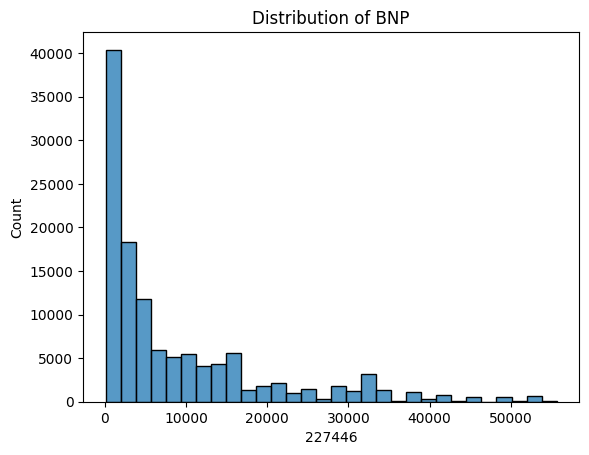

In [145]:
# BNP
sns.histplot(bnp_temp['227446'], bins=30)
plt.title('Distribution of BNP')
plt.show()

In [146]:
print(df_soft['227446'].median())
print(df_soft['227429'].median())
print(df_soft['225624'].median())
print(df_soft['220615'].median())
print(df_soft['spo2_fio2'].median())
print(df_soft['223835'].median())
print(df_soft['227456'].median())
print(df_soft['223761'].median())
print(df_soft['225668'].median())

3972.0
0.05
22.0
1.0
240.0
0.4
3.0
36.888888888888886
1.4


In [ ]:
# # def valid_features(row, col):
# #     return (row[col] != -2)

# """윤주흥 교수님 comment"""
# # 환자가 저산소증이 있으면 cardio 환자라고 하더라도 NCPE 지표도 떨어지기는 함.
# # 그리고 NCPE early stage는 CPE와 Overlap이 많이 됨.

# MEDIANS = {
#     '227446': 3972.0,
#     '227429': 0.05,
#     '225624': 22.0,
#     '220615': 1.0,
#     'spo2_fio2': 240.0,
#     '223835': 0.4,
#     '227456': 3.0,
#     '223761': 36.888888888888886,
#     '225668': 1.4
# }

# def is_meaningful_signal(row, col):
#     """
#     ffill로 인해 꽉 차 있는 데이터 중, 
#     1) 결측값 기호(-2)가 아니고
#     2) 해당 변수의 '기저 중위값(Median)'과 똑같은 값이 연속해서 채워져 있는 상태가 아닌 진짜 변별력 있는 상위 신호(Signal)인지 체크합니다.
#     """
#     val = row[col]
        
#     # ffill로 인해 글로벌 중위값이 그대로 박혀있는 경우는 환자의 실시간 급성 변화를 나타내는 '유의미한 신호'가 아니라고 보고 제외
#     if np.isclose(val, MEDIANS.get(col, -999)):
#         return False
        
#     return True

# def silver_standard_for_edema(row):
#     """
#     - 현재 방식에서는 Medication의 input amount가 반영되지 않고, 사용 여부만 반영되었음.
#     """
#     cpe_score = 0.0
#     ncpe_score = 0.0

#     # ==================================== Lab ====================================
#     # Cardio
#     # ----- (1) BNP -----
#     if is_meaningful_signal(row, '227446'):
#         bnp = row['227446']
#         if bnp >= 5000:
#             cpe_score += 3.0

#         elif bnp >= MEDIANS['227446']:
#             cpe_score += 2.0

#         elif bnp > 500:
#             cpe_score += 1.0

#     # ----- (2) Troponin-T -----
#     if is_meaningful_signal(row, '227429'):
#         troponin = row['227429']
#         if troponin >= 1.0:
#             cpe_score += 1.5

#         elif troponin >= 0.5:
#             cpe_score += 1.0

#         elif troponin >= 0.0135:
#             cpe_score += 0.25

#     # ----- (3) BUN/Creatinine
#     if is_meaningful_signal(row, '225624'):
#         bun = row['225624']

#         if is_meaningful_signal(row, '220615') and row['220615'] > 0:
#             cr = row['220615']
#             bun_cr_ratio = bun / cr
#             if bun_cr_ratio > 20:
#                 cpe_score += 1.0
#             elif bun >= 26:
#                 cpe_score += 0.5
#         else:
#             if bun >= 26:
#                 cpe_score += 0.5

#     # Non-cardio
#     # ----- (1) SpO₂ / FiO₂ -----
#     spo2_fio2 = row.get('spo2_fio2')
#     fio2 = row.get('223835')

#     has_spo2_fio2 = (spo2_fio2 != -2) and (pd.notna(spo2_fio2))
#     has_fio2 = (fio2 != -2) and (pd.notna(fio2))

#     if has_spo2_fio2:
#         if spo2_fio2 < 150:
#             ncpe_score += 2.0   # 중증 ARDS 성향
#         elif 150 <= spo2_fio2 < 235: 
#             ncpe_score += 1.0
#         elif 235 <= spo2_fio2 < 315: 
#             # [윤주흥 교수님 피드백] Cardio 환자도 저산소증이 오면 지표가 떨어지므로(Overlap),
#             # 기존의 cpe_score == 0 제약을 제거하고 조기 징후 가점으로 독립 인정
#             ncpe_score += 0.5

#     # ----- (2) FiO₂ -----
#     if has_fio2 and fio2 >= 0.6:
#         ncpe_score += 0.5

#     # ----- (3) Interaction (산소 공급 대비 폐 반응성 저하) ----
#     if has_spo2_fio2 and has_fio2:
#         if (spo2_fio2 < 235) and (fio2 >= 0.50): 
#             ncpe_score += 0.5
#         if (spo2_fio2 < 150) and (fio2 >= 0.60): 
#             ncpe_score += 1.0

#     # ----- (4) Albumin -----
#     if is_meaningful_signal(row, '227456'):
#         albumin = row['227456']
#         if albumin < 2.9:
#             ncpe_score += 0.5
#         elif albumin < 3.5:
#             ncpe_score += 0.25

#     # ----- (5) Temperature -----
#     if is_meaningful_signal(row, '223761'):
#         temperature = row['223761']
#         if temperature > 38.3:
#             ncpe_score += 0.25

#     # ----- (6) Lactate & Temperature Interaction -----
#     if is_meaningful_signal(row, '225668') and is_meaningful_signal(row, '223761'):
#         lactate = row['225668']
#         temperature = row['223761']
        
#         # 고열(감염 징후)이 동반된 고젖산혈증인 경우에만 패혈증성(NCPE) 폐손상으로 간주
#         # (심인성 쇼크로 인한 단순 조직 관류 저하와 구분)
#         if lactate >= 2.0 and temperature > 38.3:
#             ncpe_score += 1.0

#     # -------- 최종 라벨 결정 --------
#     score_diff = cpe_score - ncpe_score
#     abs_diff = abs(score_diff)

#     # 약물(1.0~1.5점)이 배제되어 전체 점수 상한이 낮아진 환경을 반영
#     MIN_SCORE = 1.0  # 타겟 증상이 존재한다고 볼 최소 단서 (경미한 소견 포착)
#     MARGIN = 0.5     # 특정 Subtype이 '우세'하다고 판단할 최소 점수 격차

#     has_cpe = (cpe_score >= MIN_SCORE)
#     has_ncpe = (ncpe_score >= MIN_SCORE)

#     # 1. 의미 있는 임상적 단서가 아예 없는 경우
#     if not has_cpe and not has_ncpe:
#         label = np.nan
        
#     # 2. CPE 압도적 우세
#     elif score_diff > MARGIN:
#         label = 2.0   
        
#     # 3. NCPE 압도적 우세
#     elif score_diff < -MARGIN:
#         label = 1.0   
        
#     # 4. 양쪽 소견이 모두 관찰되면서, 특정 한 쪽으로 치우치지 않은 모든 경우
#     elif has_cpe and has_ncpe:
#         label = 0.0
        
#     else:
#         if score_diff > 0:
#             label = 2.0   # CPE 경향
#         elif score_diff < 0:
#             label = 1.0   # NCPE 경향
#         else:
#             label = 0.0

#     return pd.Series({
#         'label': label,
#         'cpe_score': cpe_score,
#         'ncpe_score': ncpe_score,
#         'score_diff': score_diff,
#         'abs_diff': abs_diff
#     })

227429: median=0.07, p25=0.01, p75=0.35, p90=1.42


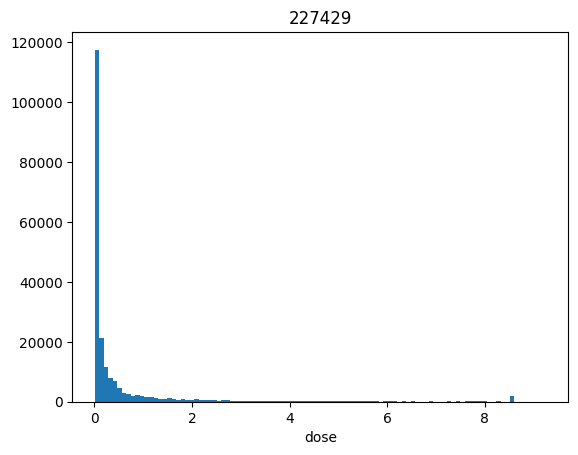

In [ ]:
# labs = ['227429'] # troponin-T
# for lab in labs:
#     values = icu_events_df[icu_events_df[lab] > 0][lab]
#     print(f"{lab}: median={values.median():.2f}, p25={values.quantile(0.25):.2f}, p75={values.quantile(0.75):.2f}, p90={values.quantile(0.90):.2f}")
#     plt.figure()
#     plt.hist(values, bins=100)
#     plt.title(lab)
#     plt.xlabel('dose')
#     plt.show()

221794: median=10.03, p25=5.01, p75=20.00, p90=40.00


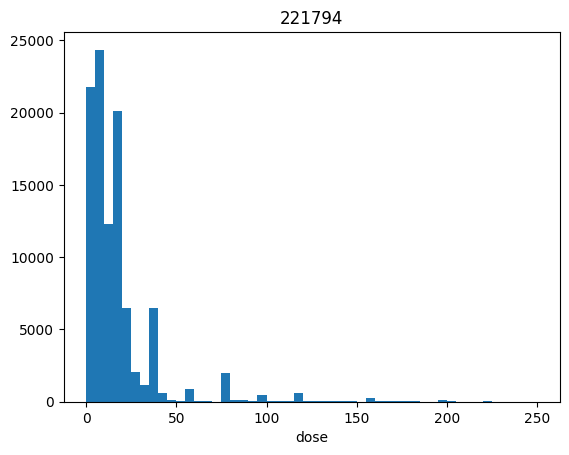

221653: median=17.63, p25=11.10, p75=25.77, p90=34.76


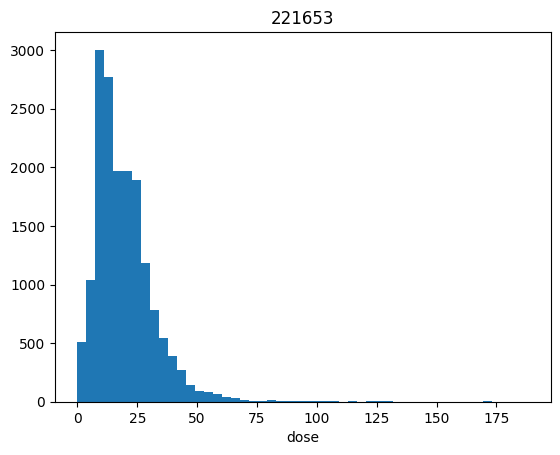

221906: median=0.43, p25=0.21, p75=0.87, p90=1.50


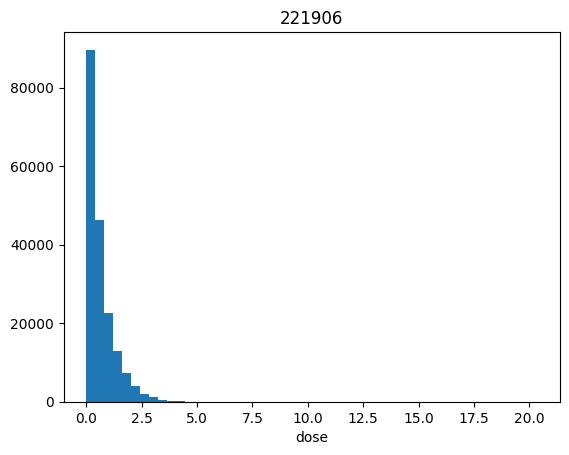

222056: median=4.01, p25=1.95, p75=7.72, p90=12.35


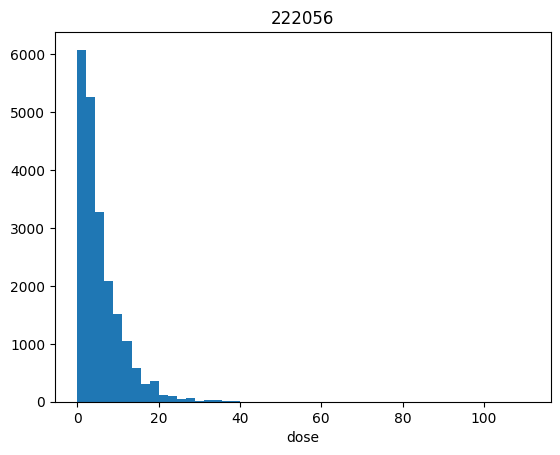

221986: median=1.38, p25=0.92, p75=1.98, p90=2.48


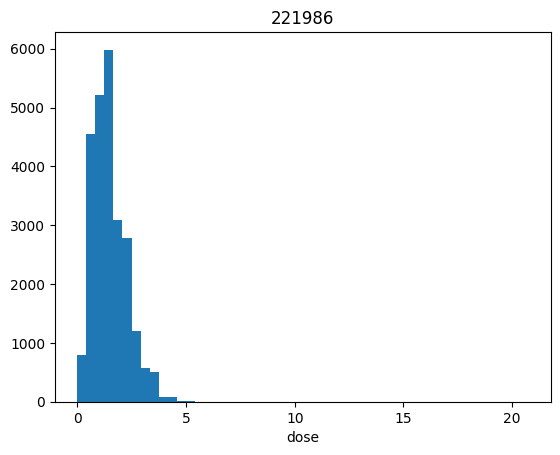

In [ ]:
# drugs = ['221794', '221653', '221906', '222056', '221986'] # Furosemide, Dobutamine, Norepinephrine, Nitroglycerin, Milrinone
# for drug in drugs:
#     values = icu_events_df[icu_events_df[drug] > 0][drug]
#     print(f"{drug}: median={values.median():.2f}, p25={values.quantile(0.25):.2f}, p75={values.quantile(0.75):.2f}, p90={values.quantile(0.90):.2f}")
#     plt.figure()
#     plt.hist(values, bins=50)
#     plt.title(drug)
#     plt.xlabel('dose')
#     plt.show()

In [82]:
test = df_soft.copy()

mask = test['Edema'] == 1.0
silver_results = test.loc[mask].apply(silver_standard_for_edema, axis=1)

# Edema=1인 행에만 값 할당
test.loc[mask, 'subtype_label'] = silver_results['label']
test.loc[mask, 'cpe_score'] = silver_results['cpe_score']
test.loc[mask, 'ncpe_score'] = silver_results['ncpe_score']
test.loc[mask, 'score_diff'] = silver_results['score_diff']

print(test['subtype_label'].value_counts(dropna=False))

subtype_label
NaN    2407868
1.0       5042
2.0       3204
0.0       2035
Name: count, dtype: int64


In [83]:
df_soft['227446'].median()

3972.0

- 주요 라벨링 분포 지표

In [84]:
analysis_df = test[test["Edema"]==1]
analysis_df = analysis_df[['stay_id', 'slot_idx', 'subtype_label', 'cpe_score', 'ncpe_score', 'score_diff']].reset_index(drop=True)

In [85]:
analysis_df

,stay_id,slot_idx,subtype_label,cpe_score,ncpe_score,score_diff
0,30000646,9,1.0,0.25,4.25,-4.00
1,30000646,61,1.0,0.25,4.00,-3.75
2,30000646,108,1.0,0.25,4.00,-3.75
3,30004391,128,2.0,1.25,0.75,0.50
4,30004391,174,2.0,1.25,0.75,0.50
...,...,...,...,...,...,...
12982,39996044,98,0.0,1.00,1.00,0.00
12983,39996044,124,0.0,1.00,1.00,0.00
12984,39996044,224,2.0,1.00,0.50,0.50
12985,39998622,80,1.0,1.00,1.75,-0.75


In [86]:
test.groupby('subtype_label')[['cpe_score','ncpe_score','score_diff']].mean()

,cpe_score,ncpe_score,score_diff
subtype_label,,,
0.0,1.249263,1.385627,-0.136364
1.0,0.531089,2.535254,-2.004165
2.0,1.612750,0.625936,0.986813


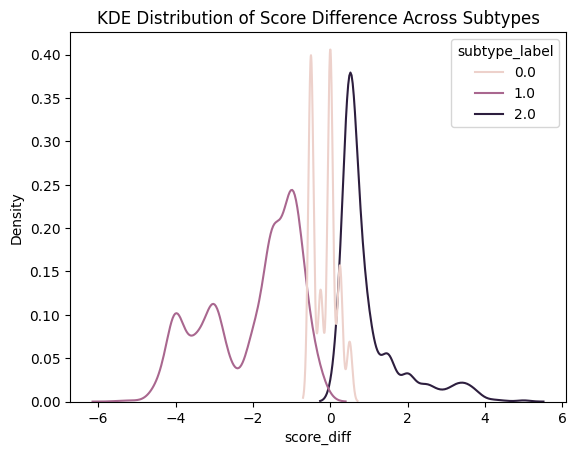

In [87]:
sns.kdeplot(data=test, x="score_diff", hue="subtype_label")
plt.title("KDE Distribution of Score Difference Across Subtypes")
plt.show()

In [89]:
MEDIANS = {
    '227446': 3972.0,
    '227429': 0.05,
    '225624': 22.0,
    '220615': 1.0,
    'spo2_fio2': 240.0,
    '223835': 0.4,
    '227456': 3.0,
    '223761': 36.888888888888886,
    '225668': 1.4
}

itemid_df = pd.read_parquet("/home/DAHS1/gangmin/my_research/data/mimic-iv/icu/parquet/d_items.parquet")
itemid_df['itemid'] = itemid_df['itemid'].astype(str)

analysis_df = test[(test['Edema'] == 1) & (test['subtype_label'].notna())].copy()

FEATURES = [
    '227446','227429','225624', '220615',
    'spo2_fio2', '223835', '227456', '223761', '225668'
]

def compute_group_stats(df, features):
    rows = []
    for f in features:
        if f not in df.columns:
            continue
        
        valid = df[df[f] != -2]

        if f in MEDIANS:
            valid = valid[~np.isclose(valid[f], MEDIANS[f])]
        
        for label in [0.0, 1.0, 2.0]:
            sub = valid[valid['subtype_label'] == label]

            if len(sub) > 0:
                rows.append({
                    "feature": f,
                    "label": label,
                    "median": sub[f].median(),
                    "mean": sub[f].mean(),
                    "n": len(sub)
                })
            else:
                rows.append({
                    "feature": f,
                    "label": label,
                    "median": np.nan,
                    "mean": np.nan,
                    "n": 0
                })
    
    return pd.DataFrame(rows)

stats_df = compute_group_stats(analysis_df, FEATURES)
stats_pivot = stats_df.pivot(index='feature', columns='label', values='median')

stats_pivot = stats_pivot.merge(
    itemid_df[['itemid', 'label']].rename(columns={'itemid': 'feature'}),
    on='feature',
    how='left'
)

stats_pivot = stats_pivot[['feature', 'label'] + [col for col in stats_pivot.columns if col not in ['feature', 'label']]]
stats_pivot

,feature,label,0.0,1.0,2.0
0,220615,Creatinine (serum),1.100000,1.200000,1.200000
1,223761,Temperature Fahrenheit,36.944444,36.944444,36.833333
2,223835,Inspired O2 Fraction,0.500000,0.600000,0.350000
3,225624,BUN,30.000000,24.000000,33.000000
4,225668,Lactic Acid,1.500000,1.600000,1.300000
5,227429,Troponin-T,0.080000,0.040000,0.140000
6,227446,Brain Natiuretic Peptide (BNP),2514.500000,1537.000000,9322.000000
7,227456,Albumin,2.600000,2.800000,3.300000
8,spo2_fio2,NaN,200.000000,182.000000,245.000000


In [90]:
test.groupby('subtype_label')['score_diff'].describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99])

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
subtype_label,,,,,,,,,,,,,,
0.0,2035.0,-0.136364,0.312717,-0.50,-0.50,-0.50,-0.5,-0.5,0.0,0.0,0.25,0.50,0.50,0.50
1.0,5042.0,-2.004165,1.185374,-5.50,-4.50,-4.00,-4.0,-3.0,-1.5,-1.0,-0.75,-0.50,-0.25,-0.25
2.0,3204.0,0.986813,0.858331,0.25,0.25,0.25,0.5,0.5,0.5,1.0,2.25,3.25,3.75,5.00


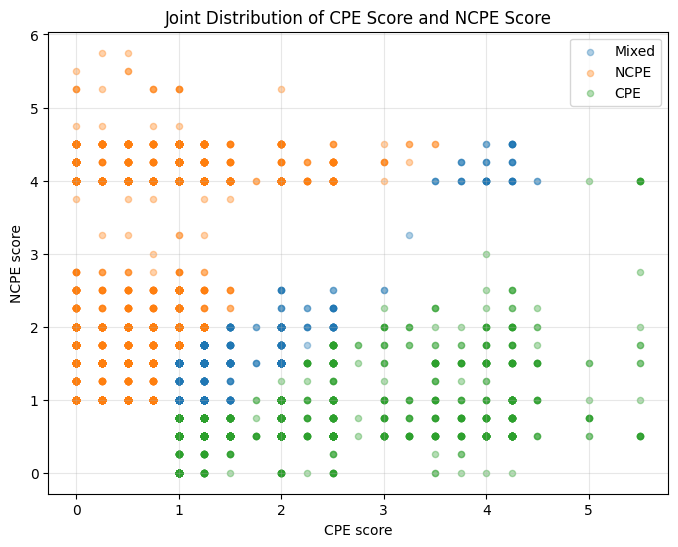

In [91]:
def plot_joint_distribution_scatter(df, label_col='label',
                                    cpe_col='cpe_score',
                                    ncpe_col='ncpe_score'):
    plot_df = df[[label_col, cpe_col, ncpe_col]].dropna().copy()

    label_map = {
        0.0: 'Mixed',
        1.0: 'NCPE',
        2.0: 'CPE'
    }
    plot_df['label_name'] = plot_df[label_col].map(label_map)

    plt.figure(figsize=(8, 6))

    for label_value, label_name in label_map.items():
        sub = plot_df[plot_df[label_col] == label_value]
        if len(sub) == 0:
            continue
        plt.scatter(
            sub[cpe_col],
            sub[ncpe_col],
            alpha=0.35,
            s=20,
            label=label_name
        )

    plt.xlabel('CPE score')
    plt.ylabel('NCPE score')
    plt.title('Joint Distribution of CPE Score and NCPE Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_joint_distribution_scatter(test, label_col='subtype_label', cpe_col='cpe_score', ncpe_col='ncpe_score')

In [148]:
test_2 = df_soft.copy()

In [149]:
def is_meaningful_signal(row, col):
    val = row[col]
    if val == -2 or pd.isna(val): return False
    if np.isclose(val, MEDIANS.get(col, -999)): return False
    return True

def softmax(logits):
    exp_logits = np.exp(logits - np.max(logits))
    return exp_logits / np.sum(exp_logits)

def process_silver_standard_pipeline(row):
    cpe_score = 0.0
    ncpe_score = 0.0

    # ----- [CPE 점수 산정] -----
    if is_meaningful_signal(row, '227446'):
        bnp = row['227446']
        if bnp >= 5000: cpe_score += 3.0
        elif bnp >= MEDIANS['227446']: cpe_score += 2.0
        elif bnp > 500: cpe_score += 1.0

    if is_meaningful_signal(row, '227429'):
        troponin = row['227429']
        if troponin >= 1.0: cpe_score += 1.5
        elif troponin >= 0.5: cpe_score += 1.0
        elif troponin >= 0.0135: cpe_score += 0.25

    if is_meaningful_signal(row, '225624'):
        bun = row['225624']
        if is_meaningful_signal(row, '220615') and row['220615'] > 0:
            cr = row['220615']
            if (bun / cr) > 20: cpe_score += 1.0
            elif bun >= 26: cpe_score += 0.5
        else:
            if bun >= 26: cpe_score += 0.5

    # ----- [NCPE 점수 산정] -----
    spo2_fio2, fio2 = row.get('spo2_fio2'), row.get('223835')
    has_spo2_fio2 = (spo2_fio2 != -2) and (pd.notna(spo2_fio2))
    has_fio2 = (fio2 != -2) and (pd.notna(fio2))

    if has_spo2_fio2:
        if spo2_fio2 < 150: ncpe_score += 2.0
        elif 150 <= spo2_fio2 < 235: ncpe_score += 1.0
        elif 235 <= spo2_fio2 < 315: ncpe_score += 0.5

    if has_fio2 and fio2 >= 0.6: ncpe_score += 0.5

    if has_spo2_fio2 and has_fio2:
        if (spo2_fio2 < 235) and (fio2 >= 0.50): ncpe_score += 0.5
        if (spo2_fio2 < 150) and (fio2 >= 0.60): ncpe_score += 1.0

    if is_meaningful_signal(row, '227456'):
        albumin = row['227456']
        if albumin < 2.9: ncpe_score += 0.5
        elif albumin < 3.5: ncpe_score += 0.25

    if is_meaningful_signal(row, '223761'):
        if row['223761'] > 38.3: ncpe_score += 0.25

    if is_meaningful_signal(row, '225668') and is_meaningful_signal(row, '223761'):
        if row['225668'] >= 2.0 and row['223761'] > 38.3: ncpe_score += 1.0

    # ----- [Hard Label 결정] -----
    score_diff = cpe_score - ncpe_score
    MIN_SCORE, MARGIN = 1.0, 0.5
    has_cpe = (cpe_score >= MIN_SCORE)
    has_ncpe = (ncpe_score >= MIN_SCORE)

    if not has_cpe and not has_ncpe:                 hard_label = np.nan
    elif has_cpe and has_ncpe and (abs(score_diff) <= MARGIN): hard_label = 0.0  # Mixed
    elif score_diff > MARGIN:                        hard_label = 2.0  # CPE
    elif score_diff < -MARGIN:                       hard_label = 1.0  # NCPE
    else:                                            hard_label = np.nan

    # ----- [★ Soft Label & ★ 선생님이 지적하신 마스크 생성] -----
    # Hard Label이 정상적으로 계산된 행(약 13,000행)만 마스크를 1로 켭니다.
    if pd.notna(hard_label):
        subtype_mask = 1.0
        # 로짓 변환 및 소프트맥스 분포 생성
        z_cpe = cpe_score
        z_ncpe = ncpe_score
        z_mixed = min(cpe_score, ncpe_score) * 1.5
        probs = softmax(np.array([z_mixed, z_ncpe, z_cpe]))
        p_mixed, p_ncpe, p_cpe = probs[0], probs[1], probs[2]
    else:
        # 데이터가 부족해 라벨링이 불가능한 200만 행 구간
        subtype_mask = 0.0
        p_mixed = p_ncpe = p_cpe = 0.0

    return pd.Series({
        'subtype_label': hard_label,
        'cpe_score': cpe_score,
        'ncpe_score': ncpe_score,
        'score_diff': score_diff,
        'subtype_mask': subtype_mask,
        'p_mixed': p_mixed, 'p_ncpe': p_ncpe, 'p_cpe': p_cpe
    })

test_2['subtype_label'] = np.nan
test_2['cpe_score'] = 0.0
test_2['ncpe_score'] = 0.0
test_2['score_diff'] = 0.0
test_2['subtype_mask'] = 0.0
test_2['p_mixed'] = 0.0
test_2['p_ncpe'] = 0.0
test_2['p_cpe'] = 0.0

# 2. 부종 환자 마스크 선언
mask = test_2['Edema'] == 1.0

# 3. 오직 부종 환자 행(약 13,000개 추정)에 대해서만 연산 수행 (매우 빠름)
silver_results = test_2.loc[mask].apply(process_silver_standard_pipeline, axis=1)

# 4. 계산된 타겟 행에만 값 덮어쓰기
target_cols = ['subtype_label', 'cpe_score', 'ncpe_score', 'score_diff', 'subtype_mask', 'p_mixed', 'p_ncpe', 'p_cpe']
test_2.loc[mask, target_cols] = silver_results[target_cols]

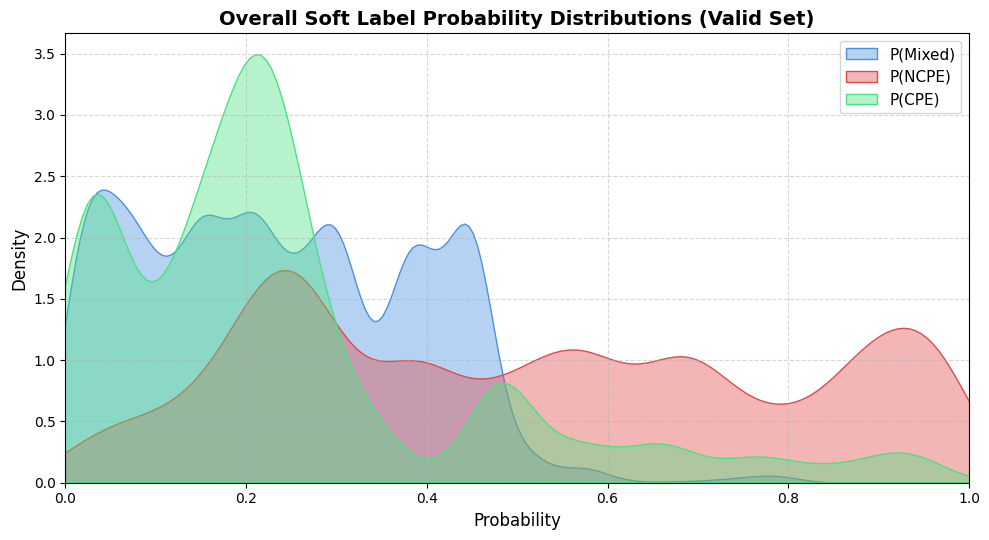

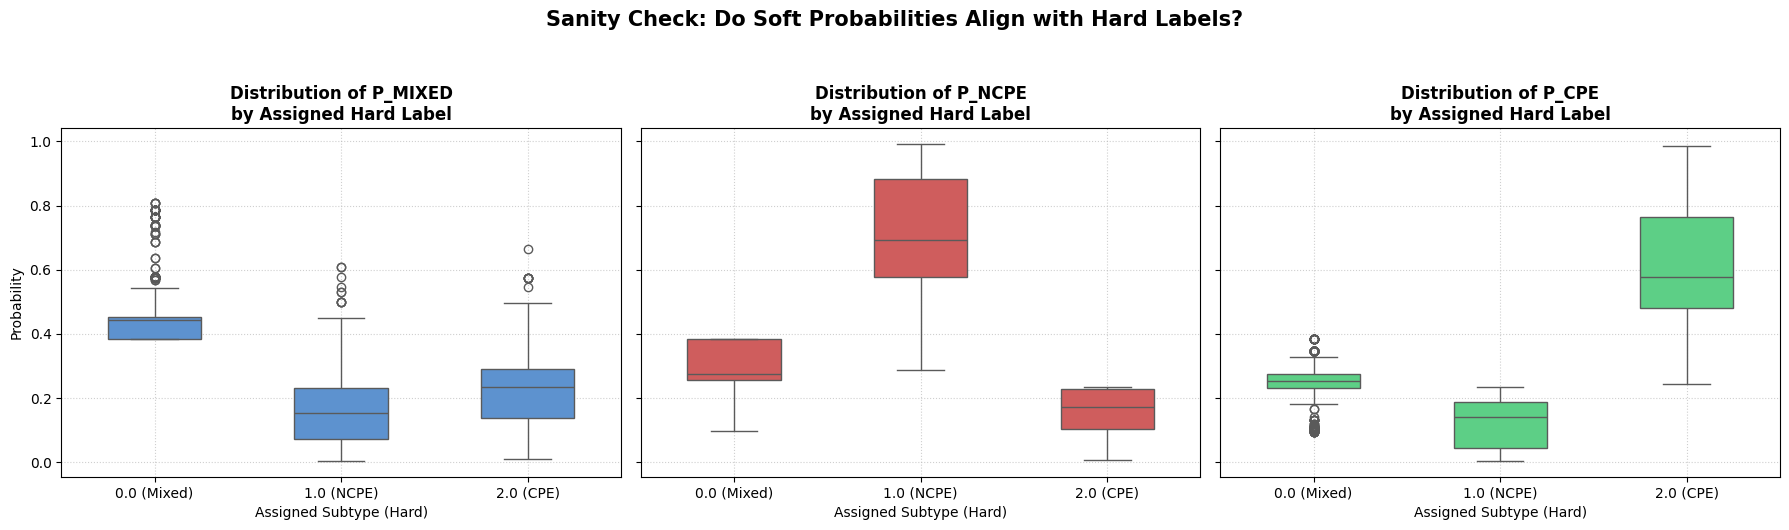

In [150]:
# 1. 서브타입 라벨이 존재하는 유효한 13,000행만 추출
plot_df = test_2[test_2['subtype_mask'] == 1.0].copy()

# 하드 라벨 시각화 편의를 위해 문자열 매핑 컬럼 추가
label_map = {0.0: '0.0 (Mixed)', 1.0: '1.0 (NCPE)', 2.0: '2.0 (CPE)'}
plot_df['hard_label_name'] = plot_df['subtype_label'].map(label_map)

# =====================================================================
# [시각화 1] 3개 클래스 확률의 전체 분포 비교 (Overlaid KDE Plot)
# =====================================================================
plt.figure(figsize=(10, 5.5))

# 각 확률 컬럼의 밀도 그리기
sns.kdeplot(data=plot_df['p_mixed'], fill=True, label='P(Mixed)', color='#4A90E2', alpha=0.4)
sns.kdeplot(data=plot_df['p_ncpe'], fill=True, label='P(NCPE)', color='#E24A4A', alpha=0.4)
sns.kdeplot(data=plot_df['p_cpe'], fill=True, label='P(CPE)', color='#4AE280', alpha=0.4)

plt.title('Overall Soft Label Probability Distributions (Valid Set)', fontsize=14, fontweight='bold')
plt.xlabel('Probability', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 1)  # 확률이므로 0에서 1 사이
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

# =====================================================================
# [시각화 2] 하드 라벨 구역별 소프트 라벨의 정합성 검증 (Grouped Boxplot)
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
prob_cols = ['p_mixed', 'p_ncpe', 'p_cpe']
colors = ['#4A90E2', '#E24A4A', '#4AE280']
order = ['0.0 (Mixed)', '1.0 (NCPE)', '2.0 (CPE)']

for i, (col, color) in enumerate(zip(prob_cols, colors)):
    sns.boxplot(
        ax=axes[i], 
        x='hard_label_name', 
        y=col, 
        data=plot_df, 
        order=order,
        color=color,
        width=0.5
    )
    axes[i].set_title(f'Distribution of {col.upper()}\nby Assigned Hard Label', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Assigned Subtype (Hard)', fontsize=10)
    axes[i].set_ylabel('Probability' if i == 0 else '', fontsize=10)
    axes[i].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Sanity Check: Do Soft Probabilities Align with Hard Labels?', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [151]:
test_2.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'slot_idx', '220045', '220210',
       '220277', '220546', '220615', '220645', '223761', '223835', '225624',
       '225668', '227073', '227429', '227442', '227445', '227446', '227456',
       'spo2_fio2', 'sbp', 'dbp', 'urine', 'cryst_weight', 'intime', 'outtime',
       'cxr_flag', 'Consolidation', 'Pneumonia', 'Cardiomegaly', 'Edema',
       'report', 'txt_path', 'raddino_emb_path', 'hybrid_emb_path',
       'stay_expire_flag', 'Edema_soft', 'subtype_label', 'cpe_score',
       'ncpe_score', 'score_diff', 'subtype_mask', 'p_mixed', 'p_ncpe',
       'p_cpe'],
      dtype='object')

---

## 데이터 최종 전처리 부분

In [152]:
test_2['subtype_label'].value_counts(dropna=False)

subtype_label
NaN    2409822
1.0       4745
0.0       2035
2.0       1547
Name: count, dtype: int64

In [153]:
final_ts_df = test_2.copy()

In [154]:
final_ts_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'slot_idx', '220045', '220210',
       '220277', '220546', '220615', '220645', '223761', '223835', '225624',
       '225668', '227073', '227429', '227442', '227445', '227446', '227456',
       'spo2_fio2', 'sbp', 'dbp', 'urine', 'cryst_weight', 'intime', 'outtime',
       'cxr_flag', 'Consolidation', 'Pneumonia', 'Cardiomegaly', 'Edema',
       'report', 'txt_path', 'raddino_emb_path', 'hybrid_emb_path',
       'stay_expire_flag', 'Edema_soft', 'subtype_label', 'cpe_score',
       'ncpe_score', 'score_diff', 'subtype_mask', 'p_mixed', 'p_ncpe',
       'p_cpe'],
      dtype='object')

In [155]:
final_ts_df['subtype_mask'].value_counts()

subtype_mask
0.0    2409822
1.0       8327
Name: count, dtype: int64

In [156]:
final_ts_df[final_ts_df['subtype_mask']==1]['Edema'].value_counts()

Edema
1.0    8327
Name: count, dtype: int64

In [157]:
value_cols = [
    '220045', '220210',
    '220277', '220546', '220615', '220645', '223761', '223835', '225624',
    '225668', '227073', '227429', '227442', '227445', '227446', '227456',
    'spo2_fio2', 'sbp', 'dbp', 'urine', 'cryst_weight'
]

In [158]:
# label_cols = [
#     'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 
#     'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices'
# ]

label_cols = [
    'Edema', 'Edema_soft', 'subtype_label', 'subtype_mask', 'p_mixed', 'p_ncpe', 'p_cpe'
]

In [159]:
df_masks = final_ts_df[['subject_id', 'hadm_id', 'stay_id', 'slot_idx'] + value_cols + label_cols]

In [160]:
df_masks.loc[:, 'subject_id'] = df_masks['subject_id'].astype(int)

In [161]:
df_masks = df_masks.merge(key_id_icu, how='left', on=['subject_id', 'hadm_id', 'stay_id'])
df_masks = df_masks.sort_values(by=['subject_id', 'hadm_id', 'stay_id', 'slot_idx']).reset_index(drop=True)
df_masks

,subject_id,hadm_id,stay_id,slot_idx,220045,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,sbp,dbp,urine,cryst_weight,Edema,Edema_soft,subtype_label,subtype_mask,p_mixed,p_ncpe,p_cpe
0,10001884,26184834,37510196,0,38.0,20.0,97.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,242.500000,180.0,12.0,29.473057,0.865663,1.0,1.0,NaN,0.0,0.0,0.0,0.0
1,10001884,26184834,37510196,1,60.0,10.0,98.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,245.000000,167.0,49.0,29.473057,1.057026,NaN,1.0,NaN,0.0,0.0,0.0,0.0
2,10001884,26184834,37510196,2,60.0,10.0,98.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,245.000000,167.0,49.0,29.473057,0.244770,NaN,1.0,NaN,0.0,0.0,0.0,0.0
3,10001884,26184834,37510196,3,72.0,20.0,100.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,250.000000,102.0,63.0,29.473057,0.244770,NaN,1.0,NaN,0.0,0.0,0.0,0.0
4,10001884,26184834,37510196,4,71.0,17.5,90.0,18.4,1.1,135.5,35.400000,0.40,30.0,1.5,11.0,0.08,3.975,14.0,3972.0,3.5,225.000000,110.0,76.0,29.473057,0.261427,NaN,1.0,NaN,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2418144,19999987,23865745,36195440,89,93.0,20.0,100.0,11.6,1.2,147.0,37.000000,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,285.714286,163.0,120.0,14.728097,0.000000,NaN,NaN,NaN,0.0,0.0,0.0,0.0
2418145,19999987,23865745,36195440,90,92.0,23.0,100.0,11.6,1.2,147.0,37.833333,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,285.714286,163.0,120.0,1.963746,0.000000,NaN,NaN,NaN,0.0,0.0,0.0,0.0
2418146,19999987,23865745,36195440,91,92.0,23.0,100.0,11.6,1.2,147.0,37.833333,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,285.714286,163.0,120.0,0.000000,2.668127,NaN,NaN,NaN,0.0,0.0,0.0,0.0
2418147,19999987,23865745,36195440,92,87.0,24.0,98.0,11.6,1.2,147.0,37.000000,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,280.000000,143.0,107.0,0.000000,0.000000,NaN,NaN,NaN,0.0,0.0,0.0,0.0


In [162]:
from preprocess.scaling_functions import (
    feature_specific_scaling_fit,
    feature_specific_scaling_transform,
    create_precise_flags,
    save_scaling_stats,
    load_scaling_stats
)

# from preprocess.split_functions import split_by_stay_id
# from preprocess.split_functions import split_by_subject_stratified

In [163]:
itemid_df = pd.read_parquet("/home/DAHS1/gangmin/my_research/data/mimic-iv/icu/parquet/d_items.parquet")
# 파생변수나 lab은 안 보임.
itemid_df['itemid'] = itemid_df['itemid'].astype(str)
itemid_df[itemid_df['itemid'].isin(value_cols)].reset_index(drop=True)

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
0,220045,Heart Rate,HR,chartevents,Routine Vital Signs,bpm,Numeric,NaN,NaN
1,220210,Respiratory Rate,RR,chartevents,Respiratory,insp/min,Numeric,NaN,NaN
2,220277,O2 saturation pulseoxymetry,SpO2,chartevents,Respiratory,%,Numeric,NaN,NaN
3,220546,WBC,WBC,chartevents,Labs,None,Numeric,NaN,NaN
4,220615,Creatinine (serum),Creatinine (serum),chartevents,Labs,None,Numeric,NaN,NaN
5,220645,Sodium (serum),Sodium (serum),chartevents,Labs,None,Numeric,NaN,NaN
6,223761,Temperature Fahrenheit,Temperature F,chartevents,Routine Vital Signs,°F,Numeric,NaN,NaN
7,223835,Inspired O2 Fraction,FiO2,chartevents,Respiratory,None,Numeric,NaN,NaN
8,225624,BUN,BUN,chartevents,Labs,None,Numeric,NaN,NaN
9,225668,Lactic Acid,Lactic Acid,chartevents,Labs,None,Numeric,NaN,NaN


In [164]:
df_masks.to_feather('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/df_masks_20260611.ftr')

---

In [2]:
df_masks = pd.read_feather('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/df_masks_20260611.ftr')

In [3]:
df_masks

,subject_id,hadm_id,stay_id,slot_idx,220045,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,sbp,dbp,urine,cryst_weight,Edema,Edema_soft,subtype_label,subtype_mask,p_mixed,p_ncpe,p_cpe
0,10001884,26184834,37510196,0,38.0,20.0,97.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,242.500000,180.0,12.0,29.473057,0.865663,1.0,1.0,NaN,0.0,0.0,0.0,0.0
1,10001884,26184834,37510196,1,60.0,10.0,98.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,245.000000,167.0,49.0,29.473057,1.057026,NaN,1.0,NaN,0.0,0.0,0.0,0.0
2,10001884,26184834,37510196,2,60.0,10.0,98.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,245.000000,167.0,49.0,29.473057,0.244770,NaN,1.0,NaN,0.0,0.0,0.0,0.0
3,10001884,26184834,37510196,3,72.0,20.0,100.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,250.000000,102.0,63.0,29.473057,0.244770,NaN,1.0,NaN,0.0,0.0,0.0,0.0
4,10001884,26184834,37510196,4,71.0,17.5,90.0,18.4,1.1,135.5,35.400000,0.40,30.0,1.5,11.0,0.08,3.975,14.0,3972.0,3.5,225.000000,110.0,76.0,29.473057,0.261427,NaN,1.0,NaN,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2418144,19999987,23865745,36195440,89,93.0,20.0,100.0,11.6,1.2,147.0,37.000000,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,285.714286,163.0,120.0,14.728097,0.000000,NaN,NaN,NaN,0.0,0.0,0.0,0.0
2418145,19999987,23865745,36195440,90,92.0,23.0,100.0,11.6,1.2,147.0,37.833333,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,285.714286,163.0,120.0,1.963746,0.000000,NaN,NaN,NaN,0.0,0.0,0.0,0.0
2418146,19999987,23865745,36195440,91,92.0,23.0,100.0,11.6,1.2,147.0,37.833333,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,285.714286,163.0,120.0,0.000000,2.668127,NaN,NaN,NaN,0.0,0.0,0.0,0.0
2418147,19999987,23865745,36195440,92,87.0,24.0,98.0,11.6,1.2,147.0,37.000000,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,280.000000,143.0,107.0,0.000000,0.000000,NaN,NaN,NaN,0.0,0.0,0.0,0.0


In [4]:
meta_cols = ['subject_id', 'hadm_id', 'stay_id', 'slot_idx', 'Edema', 'Edema_soft', 'subtype_label', 'subtype_mask', 'p_mixed', 'p_ncpe', 'p_cpe']

value_cols = [
    '220045', '220210',
    '220277', '220546', '220615', '220645', '223761', '223835', '225624',
    '225668', '227073', '227429', '227442', '227445', '227446', '227456',
    'spo2_fio2', 'sbp', 'dbp', 'urine', 'cryst_weight'
]

selected_cols = meta_cols + value_cols

df_masks = df_masks[selected_cols]

In [5]:
df_masks

,subject_id,hadm_id,stay_id,slot_idx,Edema,Edema_soft,subtype_label,subtype_mask,p_mixed,p_ncpe,p_cpe,220045,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,sbp,dbp,urine,cryst_weight
0,10001884,26184834,37510196,0,1.0,1.0,NaN,0.0,0.0,0.0,0.0,38.0,20.0,97.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,242.500000,180.0,12.0,29.473057,0.865663
1,10001884,26184834,37510196,1,NaN,1.0,NaN,0.0,0.0,0.0,0.0,60.0,10.0,98.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,245.000000,167.0,49.0,29.473057,1.057026
2,10001884,26184834,37510196,2,NaN,1.0,NaN,0.0,0.0,0.0,0.0,60.0,10.0,98.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,245.000000,167.0,49.0,29.473057,0.244770
3,10001884,26184834,37510196,3,NaN,1.0,NaN,0.0,0.0,0.0,0.0,72.0,20.0,100.0,12.2,1.1,130.0,36.888889,0.40,27.0,1.7,17.0,0.05,4.500,20.0,3972.0,3.0,250.000000,102.0,63.0,29.473057,0.244770
4,10001884,26184834,37510196,4,NaN,1.0,NaN,0.0,0.0,0.0,0.0,71.0,17.5,90.0,18.4,1.1,135.5,35.400000,0.40,30.0,1.5,11.0,0.08,3.975,14.0,3972.0,3.5,225.000000,110.0,76.0,29.473057,0.261427
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2418144,19999987,23865745,36195440,89,NaN,NaN,NaN,0.0,0.0,0.0,0.0,93.0,20.0,100.0,11.6,1.2,147.0,37.000000,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,285.714286,163.0,120.0,14.728097,0.000000
2418145,19999987,23865745,36195440,90,NaN,NaN,NaN,0.0,0.0,0.0,0.0,92.0,23.0,100.0,11.6,1.2,147.0,37.833333,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,285.714286,163.0,120.0,1.963746,0.000000
2418146,19999987,23865745,36195440,91,NaN,NaN,NaN,0.0,0.0,0.0,0.0,92.0,23.0,100.0,11.6,1.2,147.0,37.833333,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,285.714286,163.0,120.0,0.000000,2.668127
2418147,19999987,23865745,36195440,92,NaN,NaN,NaN,0.0,0.0,0.0,0.0,87.0,24.0,98.0,11.6,1.2,147.0,37.000000,0.35,22.0,1.4,11.0,1.13,4.100,38.0,3972.0,3.0,280.000000,143.0,107.0,0.000000,0.000000


In [6]:
from sklearn.model_selection import train_test_split

# 1. Data Split
print("\n" + "="*80)
print("STEP 1: Patient-level Stratified Split")
print("="*80)

subject_ids = df_masks['subject_id'].unique()

# 70%:15%:15%
train_ids, temp_ids = train_test_split(
    subject_ids, test_size=0.30, random_state=42
)

val_ids, test_ids = train_test_split(
    temp_ids, test_size=0.50, random_state=42
)

train_df = df_masks[df_masks['subject_id'].isin(train_ids)].copy().reset_index(drop=True)
val_df   = df_masks[df_masks['subject_id'].isin(val_ids)].copy().reset_index(drop=True)
test_df  = df_masks[df_masks['subject_id'].isin(test_ids)].copy().reset_index(drop=True)

print(f"Train Patients: {train_df['subject_id'].nunique()}")
print(f"Validation Patients: {val_df['subject_id'].nunique()}")
print(f"Test Patients: {test_df['subject_id'].nunique()}")


STEP 1: Patient-level Stratified Split
Train Patients: 7334
Validation Patients: 1572
Test Patients: 1572


In [7]:
train_df

,subject_id,hadm_id,stay_id,slot_idx,Edema,Edema_soft,subtype_label,subtype_mask,p_mixed,p_ncpe,p_cpe,220045,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,sbp,dbp,urine,cryst_weight
0,10002428,23473524,35479615,0,NaN,0.0,NaN,0.0,0.0,0.0,0.0,86.0,20.0,97.0,10.5,1.0,138.0,36.888889,0.4,22.0,1.4,14.0,0.05,4.0,4.0,3972.0,3.0,242.5,115.0,62.0,44.788853,0.000000
1,10002428,23473524,35479615,1,NaN,0.0,NaN,0.0,0.0,0.0,0.0,86.0,20.0,97.0,10.5,1.0,138.0,36.888889,0.4,22.0,1.4,14.0,0.05,4.0,4.0,3972.0,3.0,242.5,115.0,62.0,44.788853,0.000000
2,10002428,23473524,35479615,2,NaN,0.0,NaN,0.0,0.0,0.0,0.0,67.5,17.5,100.0,10.5,1.0,138.0,36.888889,0.4,22.0,1.4,14.0,0.05,4.0,4.0,3972.0,3.0,250.0,115.0,62.0,44.788853,0.000000
3,10002428,23473524,35479615,3,NaN,0.0,NaN,0.0,0.0,0.0,0.0,69.5,18.0,100.0,10.5,1.0,138.0,36.888889,0.4,22.0,1.4,14.0,0.05,4.0,4.0,3972.0,3.0,250.0,115.0,62.0,44.788853,0.063913
4,10002428,23473524,35479615,4,0.0,0.0,NaN,0.0,0.0,0.0,0.0,67.5,18.0,100.0,10.5,1.0,138.0,36.888889,0.4,22.0,1.4,14.0,0.05,4.0,4.0,3972.0,3.0,250.0,115.0,62.0,44.788853,4.414891
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1703246,19999287,20175828,35165301,221,NaN,0.0,NaN,0.0,0.0,0.0,0.0,80.0,16.0,97.0,10.9,0.7,141.0,36.888889,0.5,14.0,0.8,13.0,0.01,3.9,3.0,3972.0,3.0,194.0,113.0,44.0,20.779221,0.000000
1703247,19999287,20175828,35165301,222,NaN,0.0,NaN,0.0,0.0,0.0,0.0,80.0,16.0,97.0,10.9,0.7,141.0,36.888889,0.5,14.0,0.8,13.0,0.01,3.9,3.0,3972.0,3.0,194.0,113.0,44.0,0.000000,0.000000
1703248,19999287,20175828,35165301,223,NaN,NaN,NaN,0.0,0.0,0.0,0.0,97.0,16.0,94.0,10.9,0.7,141.0,36.888889,0.5,14.0,0.8,13.0,0.01,3.9,3.0,3972.0,3.0,188.0,126.0,76.0,0.000000,0.000000
1703249,19999287,20175828,35165301,224,NaN,NaN,NaN,0.0,0.0,0.0,0.0,97.0,16.0,94.0,10.9,0.7,141.0,36.888889,0.5,14.0,0.8,13.0,0.01,3.9,3.0,3972.0,3.0,188.0,126.0,76.0,0.000000,0.000000


In [ ]:
# # 2. Scaling with Train Statistics
# print("\n" + "="*80)
# print("STEP 2: Scaling with Train Statistics")
# print("="*80)

# train_scaled, scaling_stats = feature_specific_scaling_fit(
#     train_df,
#     lab_cols=lab_cols,
#     input_urine_cols=urine_fluid_cols,
#     vital_cols=vital_cols,
#     sentinel=-2
# )

# print(f"✅ Train set scaled. Shape: {train_scaled.shape}")
# print(f"✅ Scaling statistics computed for {len(scaling_stats)} columns")


STEP 2: Scaling with Train Statistics
✅ Train set scaled. Shape: (1124118, 33)
✅ Scaling statistics computed for 24 columns


In [ ]:
# train_scaled

,subject_id,hadm_id,stay_id,hour_slot,Cardiomegaly,Consolidation,Pneumonia,Edema,Edema_soft,220045,220179,220180,220210,223761,spo2_fio2,220277,223835,225624,220645,227073,227429,227442,227445,227446,227456,50963,220546,220615,225668,bun_creatinine,urine,fluid_alb,cryst_weight
0,10002428,23473524,35479615,0,NaN,NaN,NaN,NaN,0.0,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.00000,-2.000000,-2.0,-2.0,-2.0,-2.000000,-2.000000,-2.000000,-2.000000,0.000000,0.0,0.000000
1,10002428,23473524,35479615,1,NaN,NaN,NaN,NaN,0.0,-1.042353,-2.000000,-2.000000,-0.458384,-2.000000,0.469749,0.905098,-0.460234,-2.000000,-2.000000,-2.000000,-2.000000,-2.00000,-2.000000,-2.0,-2.0,-2.0,-2.000000,-2.000000,-2.000000,-2.000000,-0.585799,0.0,-0.556073
2,10002428,23473524,35479615,2,0.0,0.0,0.0,0.0,0.0,-1.098392,-2.000000,-2.000000,-0.415687,-1.377418,0.469749,0.905098,-0.460234,-2.000000,-2.000000,-2.000000,-2.000000,-2.00000,-2.000000,-2.0,-2.0,-2.0,-2.000000,-2.000000,-0.151947,-2.000000,1.883848,0.0,1.300352
3,10002428,23473524,35479615,3,0.0,0.0,0.0,0.0,0.0,-0.790174,-2.000000,-2.000000,-0.415687,-1.377418,0.469749,0.905098,-0.460234,-2.000000,-2.000000,-2.000000,-2.000000,-2.00000,-2.000000,-2.0,-2.0,-2.0,-2.000000,-2.000000,-0.151947,-2.000000,0.000000,0.0,-0.500963
4,10002428,23473524,35479615,4,NaN,NaN,NaN,NaN,0.0,-0.117699,-2.000000,-2.000000,-0.415687,-1.377418,0.424320,0.617537,-0.460234,-2.000000,-2.000000,-2.000000,-0.529115,-2.00000,0.075230,-2.0,-2.0,-2.0,-2.000000,-2.000000,-0.151947,-2.000000,-0.545056,0.0,-0.050634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1124113,19999987,23865745,36195440,42,NaN,NaN,NaN,NaN,0.0,0.610816,1.464075,1.792050,0.267468,-0.013894,-2.000000,0.042416,-2.000000,-0.136051,1.501131,-0.903803,0.979929,0.15294,1.569294,-2.0,-2.0,-2.0,0.140804,-0.061281,-2.000000,-0.297492,0.000000,0.0,0.000000
1124114,19999987,23865745,36195440,43,NaN,NaN,NaN,NaN,NaN,0.610816,1.464075,1.792050,0.267468,-0.013894,-2.000000,0.042416,-2.000000,-0.136051,1.501131,-0.903803,0.979929,0.15294,1.569294,-2.0,-2.0,-2.0,0.140804,-0.061281,-2.000000,-0.297492,0.000000,0.0,0.000000
1124115,19999987,23865745,36195440,44,NaN,NaN,NaN,NaN,NaN,0.330618,1.967165,3.590784,-0.074110,-0.013894,-2.000000,0.905098,-2.000000,-0.136051,1.501131,-0.903803,-2.000000,0.15294,-2.000000,-2.0,-2.0,-2.0,0.140804,-0.061281,-2.000000,-0.297492,1.760871,0.0,0.000000
1124116,19999987,23865745,36195440,45,NaN,NaN,NaN,NaN,NaN,0.274579,1.967165,3.590784,0.438257,1.447025,-2.000000,0.905098,-2.000000,-0.136051,1.501131,-0.903803,-2.000000,0.15294,-2.000000,-2.0,-2.0,-2.0,0.140804,-0.061281,-2.000000,-0.297492,-0.679416,0.0,0.535725


In [ ]:
# print(f"Number of soft labels in Train Dataset: {len(train_scaled[train_scaled['Edema_soft']>0])}")

Number of soft labels in Train Dataset: 433255


In [ ]:
# train_scaled.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'hour_slot', 'Cardiomegaly',
       'Consolidation', 'Pneumonia', 'Edema', 'Edema_soft', '220045', '220179',
       '220180', '220210', '223761', 'spo2_fio2', '220277', '223835', '225624',
       '220645', '227073', '227429', '227442', '227445', '227446', '227456',
       '50963', '220546', '220615', '225668', 'bun_creatinine', 'urine',
       'fluid_alb', 'cryst_weight'],
      dtype='object')

In [ ]:
# len(train_scaled.columns)

33

In [ ]:
# print("\nTransforming val set with train statistics")
# val_scaled = feature_specific_scaling_transform(val_df, scaling_stats, sentinel=-2)
# print(f"✅ Val set scaled. Shape: {val_scaled.shape}")

# print("\nTransforming test set with train statistics")
# test_scaled = feature_specific_scaling_transform(test_df, scaling_stats, sentinel=-2)
# print(f"✅ Test set scaled. Shape: {test_scaled.shape}")


Transforming val set with train statistics
✅ Val set scaled. Shape: (245604, 33)

Transforming test set with train statistics
✅ Test set scaled. Shape: (249049, 33)


In [ ]:
# # 3. Create Precise Flags
# print("\n" + "="*80)
# print("STEP 3: Creating Precise Flags")
# print("="*80)

# print("Creating flags for train set")
# train_with_flags = create_precise_flags(
#     df_raw=train_df,
#     df_scaled=train_scaled,
#     io_cols=urine_fluid_cols,
#     meta_cols=meta_cols,
#     sentinel=-2
# )

# print(f"✅ Train with flags. Shape: {train_with_flags.shape}")
# print(f"   Columns: {len(train_with_flags.columns)} (original: {len(train_scaled.columns)})")


STEP 3: Creating Precise Flags
Creating flags for train set
✅ Train with flags. Shape: (1124118, 54)
   Columns: 54 (original: 33)


In [ ]:
# train_with_flags

,subject_id,hadm_id,stay_id,hour_slot,Cardiomegaly,Consolidation,Pneumonia,Edema,Edema_soft,220045,220045_flag,220179,220179_flag,220180,220180_flag,220210,220210_flag,223761,223761_flag,spo2_fio2,spo2_fio2_flag,220277,220277_flag,223835,223835_flag,225624,225624_flag,220645,220645_flag,227073,227073_flag,227429,227429_flag,227442,227442_flag,227445,227445_flag,227446,227446_flag,227456,227456_flag,50963,50963_flag,220546,220546_flag,220615,220615_flag,225668,225668_flag,bun_creatinine,bun_creatinine_flag,urine,fluid_alb,cryst_weight
0,10002428,23473524,35479615,0,NaN,NaN,NaN,NaN,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000
1,10002428,23473524,35479615,1,NaN,NaN,NaN,NaN,0.0,-1.042353,1.0,0.000000,0.0,0.000000,0.0,-0.458384,1.0,0.000000,0.0,0.469749,1.0,0.905098,1.0,-0.460234,1.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,-0.585799,0.0,-0.556073
2,10002428,23473524,35479615,2,0.0,0.0,0.0,0.0,0.0,-1.098392,1.0,0.000000,0.0,0.000000,0.0,-0.415687,1.0,-1.377418,1.0,0.469749,1.0,0.905098,1.0,-0.460234,1.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,-0.151947,1.0,0.000000,0.0,1.883848,0.0,1.300352
3,10002428,23473524,35479615,3,0.0,0.0,0.0,0.0,0.0,-0.790174,1.0,0.000000,0.0,0.000000,0.0,-0.415687,1.0,-1.377418,1.0,0.469749,1.0,0.905098,1.0,-0.460234,1.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,-0.151947,1.0,0.000000,0.0,0.000000,0.0,-0.500963
4,10002428,23473524,35479615,4,NaN,NaN,NaN,NaN,0.0,-0.117699,1.0,0.000000,0.0,0.000000,0.0,-0.415687,1.0,-1.377418,1.0,0.424320,1.0,0.617537,1.0,-0.460234,1.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,-0.529115,1.0,0.00000,0.0,0.075230,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,-0.151947,1.0,0.000000,0.0,-0.545056,0.0,-0.050634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1124113,19999987,23865745,36195440,42,NaN,NaN,NaN,NaN,0.0,0.610816,1.0,1.464075,1.0,1.792050,1.0,0.267468,1.0,-0.013894,1.0,0.000000,0.0,0.042416,1.0,0.000000,0.0,-0.136051,1.0,1.501131,1.0,-0.903803,1.0,0.979929,1.0,0.15294,1.0,1.569294,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.140804,1.0,-0.061281,1.0,0.000000,0.0,-0.297492,1.0,0.000000,0.0,0.000000
1124114,19999987,23865745,36195440,43,NaN,NaN,NaN,NaN,NaN,0.610816,1.0,1.464075,1.0,1.792050,1.0,0.267468,1.0,-0.013894,1.0,0.000000,0.0,0.042416,1.0,0.000000,0.0,-0.136051,1.0,1.501131,1.0,-0.903803,1.0,0.979929,1.0,0.15294,1.0,1.569294,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.140804,1.0,-0.061281,1.0,0.000000,0.0,-0.297492,1.0,0.000000,0.0,0.000000
1124115,19999987,23865745,36195440,44,NaN,NaN,NaN,NaN,NaN,0.330618,1.0,1.967165,1.0,3.590784,1.0,-0.074110,1.0,-0.013894,1.0,0.000000,0.0,0.905098,1.0,0.000000,0.0,-0.136051,1.0,1.501131,1.0,-0.903803,1.0,0.000000,0.0,0.15294,1.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.140804,1.0,-0.061281,1.0,0.000000,0.0,-0.297492,1.0,1.760871,0.0,0.000000
1124116,19999987,23865745,36195440,45,NaN,NaN,NaN,NaN,NaN,0.274579,1.0,1.967165,1.0,3.590784,1.0,0.438257,1.0,1.447025,1.0,0.000000,0.0,0.905098,1.0,0.000000,0.0,-0.136051,1.0,1.501131,1.0,-0.903803,1.0,0.000000,0.0,0.15294,1.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.140804,1.0,-0.061281,1.0,0.000000,0.0,-0.297492,1.0,-0.679416,0.0,0.535725


In [8]:
len(train_df.columns) - len(meta_cols)

21

In [9]:
train_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'slot_idx', 'Edema', 'Edema_soft',
       'subtype_label', 'subtype_mask', 'p_mixed', 'p_ncpe', 'p_cpe', '220045',
       '220210', '220277', '220546', '220615', '220645', '223761', '223835',
       '225624', '225668', '227073', '227429', '227442', '227445', '227446',
       '227456', 'spo2_fio2', 'sbp', 'dbp', 'urine', 'cryst_weight'],
      dtype='object')

In [ ]:
# print("\nCreating flags for val set...")
# val_with_flags = create_precise_flags(
#     df_raw=val_df,
#     df_scaled=val_scaled,
#     io_cols=urine_fluid_cols,
#     procedure_cols=proc_cols,
#     meta_cols=meta_cols,
#     sentinel=-2
# )
# print(f"✅ Val with flags. Shape: {val_with_flags.shape}")

# print("\nCreating flags for test set...")
# test_with_flags = create_precise_flags(
#     df_raw=test_df,
#     df_scaled=test_scaled,
#     io_cols=urine_fluid_cols,
#     procedure_cols=proc_cols,
#     meta_cols=meta_cols,
#     sentinel=-2
# )
# print(f"✅ Test with flags. Shape: {test_with_flags.shape}")


Creating flags for val set...
✅ Val with flags. Shape: (245604, 54)

Creating flags for test set...
✅ Test with flags. Shape: (249049, 54)


In [32]:
# output_dir = '/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/3rd_preprocessed_data/'

# train_with_flags.to_feather(output_dir + 'train_multimodal_20260428_ssl.ftr')
# print(f"✅ Saved: {output_dir}train_multimodal_20260428_ssl.ftr")

# val_with_flags.to_feather(output_dir + 'val_multimodal_20260428_ssl.ftr')
# print(f"✅ Saved: {output_dir}val_multimodal_20260428_ssl.ftr")

# test_with_flags.to_feather(output_dir + 'test_multimodal_20260428_ssl.ftr')
# print(f"✅ Saved: {output_dir}test_multimodal_20260428_ssl.ftr")

In [10]:
cxr_text_df = pd.read_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/cached_final_cxr_df_in_icu_20260526.ftr")
cxr_text_df = cxr_text_df.drop(columns=['study_id', 'dicom_id', 'intime', 'outtime', 'Pneumonia', 'Consolidation', 'Cardiomegaly', 'Edema'])

In [11]:
cxr_text_df[(cxr_text_df['cxr_flag']==1)&(cxr_text_df['raddino_emb_path'].isnull())]

,subject_id,hadm_id,stay_id,slot_idx,cxr_flag,report,txt_path,raddino_emb_path,hybrid_emb_path


In [12]:
# # === Mean CLS 계산 (one-time, 별도 셀) ===
# import torch, os, glob
# from tqdm import tqdm

# # OLD CLS 저장 경로 (학습에 사용 중인 것)
# CLS_DIR = "/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/text_embed"

# cls_files = sorted(glob.glob(os.path.join(CLS_DIR, "*.pt")))
# print(f"총 {len(cls_files)}개 CLS 파일")

# # 누적 평균 (메모리 절약)
# running_sum = None
# n = 0
# for f in tqdm(cls_files):
#     v = torch.load(f, map_location='cpu', weights_only=True).float()   # [768]
#     if running_sum is None:
#         running_sum = torch.zeros_like(v)
#     running_sum += v
#     n += 1
# mean_cls = running_sum / n
# print(f"mean_cls 차원: {mean_cls.shape}, norm: {mean_cls.norm():.4f}")

# # 저장
# mean_path = "/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/text_cls_mean.pt"
# torch.save(mean_cls, mean_path)
# print(f"저장: {mean_path}")

In [13]:
cols_to_fix = ['subject_id', 'hadm_id', 'stay_id', 'slot_idx']

for df in [train_df, cxr_text_df]:
    for col in cols_to_fix:
        df[col] = pd.to_numeric(df[col])

In [14]:
print(train_df[['subject_id', 'hadm_id', 'stay_id', 'slot_idx']].dtypes)
print(cxr_text_df[['subject_id', 'hadm_id', 'stay_id', 'slot_idx']].dtypes)

subject_id    int64
hadm_id       int64
stay_id       int64
slot_idx      int64
dtype: object
subject_id    int64
hadm_id       int64
stay_id       int64
slot_idx      int64
dtype: object


In [16]:
cxr_text_df['stay_id'].nunique()

13438

In [15]:
import re

from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader

pubmed_tokenizer = AutoTokenizer.from_pretrained("NeuML/pubmedbert-base-embeddings")
pubmed_model = AutoModel.from_pretrained("NeuML/pubmedbert-base-embeddings")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [16]:
sentences = "cardiomediastinal contours are unchanged with cardiac size top normal. patient is extubated. diffuse bilateral left greater than right opacities have worsened. these could be secondary to noncardiogenic pulmonary edema, ards or infection. there is no pneumothorax or large effusions"

- PubMedBERT

In [17]:
# PubMedBERT

inputs = pubmed_tokenizer(sentences, padding=True, truncation=True, return_tensors='pt')


input_ids_list = inputs['input_ids']

print("--- 문장별 토큰화 결과 확인 ---")
for i, tokens in enumerate(input_ids_list):
    # 1. 숫자 ID 배열을 실제 토큰 문자열 리스트로 변환
    token_strings = pubmed_tokenizer.convert_ids_to_tokens(tokens)
    # 2. 보기 좋게 정렬해서 출력
    print(f"\n[문장 {i+1}] {sentences[i]}")
    print(f"-> 토큰 리스트: {token_strings}")
    print(f"-> ID 리스트  : {tokens.tolist()}")

--- 문장별 토큰화 결과 확인 ---

[문장 1] c
-> 토큰 리스트: ['[CLS]', 'cardio', '##medi', '##astin', '##al', 'contours', 'are', 'unchanged', 'with', 'cardiac', 'size', 'top', 'normal', '.', 'patient', 'is', 'ext', '##ubated', '.', 'diffuse', 'bilateral', 'left', 'greater', 'than', 'right', 'opac', '##ities', 'have', 'worsened', '.', 'these', 'could', 'be', 'secondary', 'to', 'nonc', '##ardi', '##ogenic', 'pulmonary', 'edema', ',', 'ards', 'or', 'infection', '.', 'there', 'is', 'no', 'pneumothorax', 'or', 'large', 'effusion', '##s', '[SEP]']
-> ID 리스트  : [2, 21129, 5476, 13845, 1923, 22061, 2032, 9913, 1956, 4435, 3081, 3700, 2791, 18, 2774, 1977, 2897, 17873, 18, 9435, 7787, 3506, 3430, 2254, 3659, 19888, 2569, 2162, 22784, 18, 2144, 2578, 1998, 4067, 1942, 9341, 3082, 3880, 5352, 10144, 16, 18618, 2014, 2909, 18, 2276, 1977, 2239, 27464, 2014, 3103, 17673, 1036, 3]


- BioclinicalBERT

In [ ]:
# # BioClinicalBERT safetensors

# model_path = "/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/models/bio_clinicalbert_safetensors"

# bc_tokenizer = AutoTokenizer.from_pretrained(model_path)
# bc_model = AutoModel.from_pretrained(model_path)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [ ]:
# # BioClinicalBERT
# bc_inputs = bc_tokenizer(sentences, padding=True, truncation=True, return_tensors='pt')

# # 토큰화 결과물(input_ids) 가져오기
# input_ids_list = bc_inputs['input_ids']

# print("--- 문장별 토큰화 결과 확인 ---")
# for i, tokens in enumerate(input_ids_list):
#     token_strings = bc_tokenizer.convert_ids_to_tokens(tokens)
#     print(f"\n[문장 {i+1}] {sentences[i]}")
#     print(f"-> 토큰 리스트: {token_strings}")
#     print(f"-> ID 리스트  : {tokens.tolist()}")

--- 문장별 토큰화 결과 확인 ---

[문장 1] c
-> 토큰 리스트: ['[CLS]', 'card', '##io', '##media', '##st', '##inal', 'con', '##tour', '##s', 'are', 'unchanged', 'with', 'cardiac', 'size', 'top', 'normal', '.', 'patient', 'is', 'ex', '##tub', '##ated', '.', 'di', '##ff', '##use', 'bilateral', 'left', 'greater', 'than', 'right', 'op', '##ac', '##ities', 'have', 'worse', '##ned', '.', 'these', 'could', 'be', 'secondary', 'to', 'non', '##card', '##io', '##genic', 'pulmonary', 'ed', '##ema', ',', 'a', '##rds', 'or', 'infection', '.', 'there', 'is', 'no', 'p', '##ne', '##um', '##oth', '##orax', 'or', 'large', 'e', '##ff', '##usions', '[SEP]']
-> ID 리스트  : [101, 3621, 2660, 16418, 2050, 14196, 14255, 18834, 1116, 1132, 16684, 1114, 17688, 2060, 1499, 2999, 119, 5351, 1110, 4252, 25098, 2913, 119, 4267, 3101, 5613, 20557, 1286, 3407, 1190, 1268, 11769, 7409, 4233, 1138, 4146, 3540, 119, 1292, 1180, 1129, 3718, 1106, 1664, 10542, 2660, 19438, 26600, 5048, 14494, 117, 170, 15093, 1137, 8974, 119, 1175, 1110, 1185,

---

In [60]:
text_df = cxr_text_df[cxr_text_df['txt_path'].notnull()].reset_index(drop=True)
text_df = text_df[['subject_id', 'hadm_id', 'stay_id', 'slot_idx', 'report']]

In [61]:
text_df

,subject_id,hadm_id,stay_id,slot_idx,report
0,10001884,26184834,37510196,0,"In comparison to ___ chest radiograph, pulmona..."
1,10001884,26184834,37510196,49,"Compared to prior chest radiographs since ___,..."
2,10001884,26184834,37510196,96,Compared to prior chest radiographs ___ throug...
3,10001884,26184834,37510196,156,In comparison to previous radiograph of 1 day ...
4,10001884,26184834,37510196,192,The endotracheal tube tip is 6 cm above the ca...
...,...,...,...,...,...
40777,19999287,20175828,35165301,162,There is interval resolution of left lung coll...
40778,19999287,20175828,35165301,198,Compared to the prior study the ET tube has be...
40779,19999442,26785317,32336619,16,ET tube ends 4.7 cm above the carina. NG tube...
40780,19999987,23865745,36195440,12,The ET tube terminates approximately 2.9 cm fr...


In [ ]:
# token_lengths = []

# for text in tqdm(text_df['report']):
#     if text.strip() == "":
#         token_lengths.append(0)
#         continue

#     tokens = bc_tokenizer.encode(text, add_special_tokens=True)
#     token_lengths.append(len(tokens))

# text_df['token_length'] = token_lengths

# token_lengths = np.array(token_lengths)
# print("\n" + "="*40)
# print(f"[Radiology report token length analysis results]")
# print("="*40)
# print(f"• Total report rows : {len(token_lengths)}")
# print(f"• Maximum token length : {np.max(token_lengths)} tokens")
# print(f"• Average token length : {np.mean(token_lengths):.2f} tokens")
# print(f"• Median token length : {np.median(token_lengths)} tokens")
# print(f"• 128 tokens exceeded : {np.sum(token_lengths > 128)} ({np.sum(token_lengths > 128) / len(token_lengths) * 100:.2f}%)")
# print("="*40)

  0%|          | 0/40782 [00:00<?, ?it/s]


[Radiology report token length analysis results]
• Total report rows : 40782
• Maximum token length : 465 tokens
• Average token length : 86.47 tokens
• Median token length : 81.0 tokens
• 128 tokens exceeded : 4937 (12.11%)


In [322]:
text_df['report']

0        In comparison to ___ chest radiograph, pulmona...
1        Compared to prior chest radiographs since ___,...
2        Compared to prior chest radiographs ___ throug...
3        In comparison to previous radiograph of 1 day ...
4        The endotracheal tube tip is 6 cm above the ca...
                               ...                        
40777    There is interval resolution of left lung coll...
40778    Compared to the prior study the ET tube has be...
40779    ET tube ends 4.7 cm above the carina.  NG tube...
40780    The ET tube terminates approximately 2.9 cm fr...
40781    There has been interval extubation and improve...
Name: report, Length: 40782, dtype: object

In [352]:
for idx, row in edema_df.tail(10).iterrows():
    print(f"==================================================")
    print(f"[Index]: {idx} | [Stay ID]: {row['stay_id']}")
    print(f"==================================================")
    print(row['report'])  # .iloc 없이 row['컬럼명']으로 출력하면 \n이 실제 줄바꿈으로 적용됩니다.
    print("\n")

[Index]: 40744 | [Stay ID]: 38607853
In comparison to the chest radiograph obtained 1 day prior, right greater than
 left left pleural effusions are probably unchanged, taking into account
 changes in patient positioning.  Bibasilar atelectasis is also unchanged. 
 Lungs are otherwise clear without focal consolidations.  Heart size and
 cardiomediastinal silhouette are unchanged.  Mild pulmonary edema has
 resolved.


[Index]: 40745 | [Stay ID]: 36805359
As compared to the previous radiograph, the pre-existing right
 pneumothorax has decreased in extent but is still clearly visible.  There are
 no signs of tension.
 
 No left-sided pneumothorax.  No pleural effusions.  Minimal pulmonary edema
 and borderline size of the cardiac silhouette.
 
 In the interval, the patient has been extubated and all other monitoring and
 support devices have been removed, except for venous introduction sheath in
 the right internal jugular vein.


[Index]: 40748 | [Stay ID]: 31629173
As compared to the p

In [350]:
text_df[text_df['stay_id']==38875437]

,subject_id,hadm_id,stay_id,slot_idx,report,token_length,cleaned_report,text_embed_path
18,10002428,28662225,38875437,64,Large right and moderate left pleural effusion...,57,Large right and moderate left pleural effusion...,/home/DAHS1/gangmin/my_research/clinical_multi...
19,10002428,28662225,38875437,82,There is decrease in now small right pleural e...,64,There is decrease in now small right pleural e...,/home/DAHS1/gangmin/my_research/clinical_multi...
20,10002428,28662225,38875437,112,"As compared to the previous radiograph, the mo...",73,"As compared to the previous radiograph, the mo...",/home/DAHS1/gangmin/my_research/clinical_multi...
21,10002428,28662225,38875437,161,A single portable chest radiograph is obtained...,84,A single portable chest radiograph is obtained...,/home/DAHS1/gangmin/my_research/clinical_multi...
22,10002428,28662225,38875437,211,Comparison is made to previous study from ___....,88,Comparison is made to previous study from ___....,/home/DAHS1/gangmin/my_research/clinical_multi...
23,10002428,28662225,38875437,247,Comparison is made to prior study from ___ at ...,94,Comparison is made to prior study from ___ at ...,/home/DAHS1/gangmin/my_research/clinical_multi...
24,10002428,28662225,38875437,248,Distal tip of the Dobbhoff is now in the fundu...,64,Distal tip of the Dobbhoff is now in the fundu...,/home/DAHS1/gangmin/my_research/clinical_multi...
25,10002428,28662225,38875437,306,Comparison is made to previous study from ___....,78,Comparison is made to previous study from ___....,/home/DAHS1/gangmin/my_research/clinical_multi...


In [182]:
token_lengths = []

for text in tqdm(text_df['report']):
    if text.strip() == "":
        token_lengths.append(0)
        continue

    tokens = pubmed_tokenizer.encode(text, add_special_tokens=True)
    token_lengths.append(len(tokens))

text_df['token_length'] = token_lengths

token_lengths = np.array(token_lengths)
print("\n" + "="*40)
print(f"[Radiology report token length analysis results]")
print("="*40)
print(f"• Total report rows : {len(token_lengths)}")
print(f"• Maximum token length : {np.max(token_lengths)} tokens")
print(f"• Average token length : {np.mean(token_lengths):.2f} tokens")
print(f"• Median token length : {np.median(token_lengths)} tokens")
print(f"• 128 tokens exceeded : {np.sum(token_lengths > 128)} ({np.sum(token_lengths > 128) / len(token_lengths) * 100:.2f}%)")
print("="*40)

  0%|          | 0/40782 [00:00<?, ?it/s]


[Radiology report token length analysis results]
• Total report rows : 40782
• Maximum token length : 395 tokens
• Average token length : 73.61 tokens
• Median token length : 69.0 tokens
• 128 tokens exceeded : 2320 (5.69%)


In [183]:
def clean_radiology_report(text):
    if not isinstance(text, str):
        return ""
    
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[-=+#*]{2,}', ' ', text)
    return text.strip()

text_df['cleaned_report'] = text_df['report'].apply(clean_radiology_report)

In [184]:
print(text_df['report'][2])

print("\n전처리 후인 위 아래를 비교해보시오\n")

print(text_df['cleaned_report'][2])

Compared to prior chest radiographs ___ through ___.
 
 Previous mild pulmonary edema has improved, moderate cardiomegaly and
 mediastinal vascular engorgement have not.  ET tube, right transjugular
 temporary pacer lead are in standard placements and an esophageal drainage
 tube passes into the stomach and out of view.  Pleural effusions are presumed
 but not substantial.  No pneumothorax.

전처리 후인 위 아래를 비교해보시오

Compared to prior chest radiographs ___ through ___. Previous mild pulmonary edema has improved, moderate cardiomegaly and mediastinal vascular engorgement have not. ET tube, right transjugular temporary pacer lead are in standard placements and an esophageal drainage tube passes into the stomach and out of view. Pleural effusions are presumed but not substantial. No pneumothorax.


In [185]:
text_df

,subject_id,hadm_id,stay_id,slot_idx,report,token_length,cleaned_report
0,10001884,26184834,37510196,0,"In comparison to ___ chest radiograph, pulmona...",26,"In comparison to ___ chest radiograph, pulmona..."
1,10001884,26184834,37510196,49,"Compared to prior chest radiographs since ___,...",95,"Compared to prior chest radiographs since ___,..."
2,10001884,26184834,37510196,96,Compared to prior chest radiographs ___ throug...,79,Compared to prior chest radiographs ___ throug...
3,10001884,26184834,37510196,156,In comparison to previous radiograph of 1 day ...,81,In comparison to previous radiograph of 1 day ...
4,10001884,26184834,37510196,192,The endotracheal tube tip is 6 cm above the ca...,101,The endotracheal tube tip is 6 cm above the ca...
...,...,...,...,...,...,...,...
40777,19999287,20175828,35165301,162,There is interval resolution of left lung coll...,63,There is interval resolution of left lung coll...
40778,19999287,20175828,35165301,198,Compared to the prior study the ET tube has be...,21,Compared to the prior study the ET tube has be...
40779,19999442,26785317,32336619,16,ET tube ends 4.7 cm above the carina. NG tube...,74,ET tube ends 4.7 cm above the carina. NG tube ...
40780,19999987,23865745,36195440,12,The ET tube terminates approximately 2.9 cm fr...,90,The ET tube terminates approximately 2.9 cm fr...


In [186]:
class ClinicalTextDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_tokens=128):
        self.df = dataframe
        self.tokenizer = tokenizer
        self.max_tokens = max_tokens
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row['cleaned_report'])
        
        encoded = self.tokenizer(
            text,
            return_tensors='pt',
            max_length=self.max_tokens,
            truncation=True,
            padding='max_length'
        )

        input_ids = encoded['input_ids'].squeeze(0).to(torch.long)
        attn_mask = encoded['attention_mask'].squeeze(0).to(torch.long)

        return {
            'input_ids': input_ids,
            'attention_mask': attn_mask,
            'stay_id': int(row['stay_id']),
            'slot_idx': int(row['slot_idx'])
        }

def extract_and_map_embeddings(df, tokenizer, output_dir, batch_size, max_tokens=128):
    os.makedirs(output_dir, exist_ok=True)
    
    dataset = ClinicalTextDataset(df, tokenizer, max_tokens)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    embedding_paths = []
    
    for batch in tqdm(dataloader):
        input_ids_batch = batch['input_ids']       # [B, 128]
        attn_mask_batch = batch['attention_mask']  # [B, 128]

        stay_ids = batch['stay_id'].tolist()
        slot_indices = batch['slot_idx'].tolist()

        for i in range(len(stay_ids)):
            stay_id = stay_ids[i]
            slot_idx = slot_indices[i]
            
            save_data = {
                'input_ids': input_ids_batch[i].clone(),
                'attention_mask': attn_mask_batch[i].clone(),
            }
            
            file_name = f"stay_{stay_id}_hour_{slot_idx}.pt"
            file_path = os.path.join(output_dir, file_name)
            
            # torch.save(save_data, file_path)
            embedding_paths.append(file_path)
    
    df['text_embed_path'] = embedding_paths
    print(f"텍스트 토큰 저장 폴더: {os.path.abspath(output_dir)}")
    return df

text_store_dir="/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/pubmed_text_ids/"
final_text_df = extract_and_map_embeddings(
    df=text_df, tokenizer=pubmed_tokenizer, output_dir=text_store_dir, batch_size=512, max_tokens=128
)

  0%|          | 0/80 [00:00<?, ?it/s]

텍스트 토큰 저장 폴더: /home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/pubmed_text_ids


In [187]:
final_text_df['text_embed_path'][0]

'/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/pubmed_text_ids/stay_37510196_hour_0.pt'

In [188]:
cxr_text_df = cxr_text_df.merge(final_text_df, on=['subject_id', 'hadm_id', 'stay_id', 'slot_idx'], how='inner')
cxr_text_df = cxr_text_df.drop(columns=['report_x', 'report_y', 'txt_path', 'token_length', 'cleaned_report'])

cxr_text_df['text_flag'] = 1

In [189]:
cxr_text_df

,subject_id,hadm_id,stay_id,slot_idx,cxr_flag,raddino_emb_path,hybrid_emb_path,text_embed_path,text_flag
0,10001884,26184834,37510196,0,1,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1
1,10001884,26184834,37510196,49,1,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1
2,10001884,26184834,37510196,96,1,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1
3,10001884,26184834,37510196,156,1,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1
4,10001884,26184834,37510196,192,1,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1
...,...,...,...,...,...,...,...,...,...
40777,19999287,20175828,35165301,162,1,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1
40778,19999287,20175828,35165301,198,1,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1
40779,19999442,26785317,32336619,16,1,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1
40780,19999987,23865745,36195440,12,1,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1


In [190]:
# 4. 이미지/텍스트 Left Join
print("\n" + "="*80)
print("STEP 3: Joining Image/Text Data")
print("="*80)
print("Merging train set")

train_final = train_df.merge(cxr_text_df, on=['subject_id', 'hadm_id', 'stay_id', 'slot_idx'], how='left')
train_final['text_flag'] = train_final['text_flag'].fillna(0) # Text flag 후속 조치
print(f"✅ Train final shape: {train_final.shape}")


STEP 3: Joining Image/Text Data
Merging train set
✅ Train final shape: (1703251, 37)


In [191]:
train_final.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'slot_idx', 'Edema', 'Edema_soft',
       'subtype_label', 'subtype_mask', 'p_mixed', 'p_ncpe', 'p_cpe', '220045',
       '220210', '220277', '220546', '220615', '220645', '223761', '223835',
       '225624', '225668', '227073', '227429', '227442', '227445', '227446',
       '227456', 'spo2_fio2', 'sbp', 'dbp', 'urine', 'cryst_weight',
       'cxr_flag', 'raddino_emb_path', 'hybrid_emb_path', 'text_embed_path',
       'text_flag'],
      dtype='object')

In [194]:
print("Merging val set")
val_final = val_df.merge(cxr_text_df, on=['subject_id', 'hadm_id', 'stay_id', 'slot_idx'], how='left')
val_final['text_flag'] = val_final['text_flag'].fillna(0) # Text flag 후속 조치
print(f"✅ Val final shape: {val_final.shape}")

print("Merging test set")
test_final = test_df.merge(cxr_text_df, on=['subject_id', 'hadm_id', 'stay_id', 'slot_idx'], how='left')
test_final['text_flag'] = test_final['text_flag'].fillna(0) # Text flag 후속 조치
print(f"✅ Test final shape: {test_final.shape}")

Merging val set
✅ Val final shape: (354938, 37)
Merging test set
✅ Test final shape: (359960, 37)


In [ ]:
# # 데이터 노트북에서 빠르게
# import pandas as pd
# df = pd.read_feather('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/train_multimodal_20260609.ftr')
# for col in ['Edema', 'Cardiomegaly', 'Pneumonia']:
#     valid = df[col].notna().sum()
#     pos = (df[col] == 1).sum()
#     total = len(df)
#     print(f"{col}: valid={valid}/{total} ({valid/total*100:.1f}%), pos={pos}/{valid} ({pos/valid*100:.1f}%)")


Edema: valid=28830/1703251 (1.7%), pos=9243/28830 (32.1%)
Cardiomegaly: valid=28830/1703251 (1.7%), pos=10739/28830 (37.2%)
Pneumonia: valid=28830/1703251 (1.7%), pos=4767/28830 (16.5%)


In [ ]:
df_chart = pd.read_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/df_chart.ftr")

key_id_icu = pd.read_feather('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/key_id_static.ftr')
key_id_icu = key_id_icu[['hadm_id', 'stay_id', 'intime', 'outtime']]

test_df = pd.read_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/test_multimodal_20260611.ftr")

df_admission = pd.read_parquet("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/core_parquet/admissions.parquet")

In [55]:
key_id_icu[key_id_icu['stay_id']==33546047]

,hadm_id,stay_id,intime,outtime
1714,27088725.0,33546047.0,2150-12-27 03:28:11,2151-01-10 22:26:48


In [58]:
df_admission[df_admission['subject_id']==11226173]

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
51971,11226173,25641529,2151-09-08 15:06:00,2151-09-12 11:30:00,None,EW EMER.,P92GJO,EMERGENCY ROOM,HOME,Other,ENGLISH,MARRIED,WHITE,2151-09-08 10:59:00,2151-09-08 15:47:00,0
51972,11226173,27088725,2150-12-27 03:26:00,2151-01-13 16:35:00,None,URGENT,P99LA7,TRANSFER FROM HOSPITAL,REHAB,Medicaid,ENGLISH,MARRIED,WHITE,None,None,0
51973,11226173,27696933,2151-07-15 01:20:00,2151-07-21 16:54:00,None,EW EMER.,P77BSD,EMERGENCY ROOM,HOME,Other,ENGLISH,MARRIED,WHITE,2151-07-14 22:41:00,2151-07-15 01:25:00,0
51974,11226173,27758545,2152-10-06 23:12:00,2152-10-09 12:25:00,None,URGENT,P3417E,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicare,ENGLISH,MARRIED,WHITE,None,None,0
51975,11226173,29595376,2155-01-16 05:48:00,2155-01-18 14:30:00,None,OBSERVATION ADMIT,P80DT1,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,ENGLISH,MARRIED,WHITE,2155-01-16 01:18:00,2155-01-16 10:46:00,0


In [35]:
key_id_icu[key_id_icu['stay_id']==32437687]

,hadm_id,stay_id,intime,outtime
7851,26495633.0,32437687.0,2124-06-13 01:29:32,2124-06-25 21:40:48


In [43]:
test_df[(test_df['spo2_fio2']<160) & (test_df['subtype_label']==1)].head(50)

,subject_id,hadm_id,stay_id,slot_idx,Edema,Edema_soft,subtype_label,subtype_mask,p_mixed,p_ncpe,p_cpe,220045,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,sbp,dbp,urine,cryst_weight,cxr_flag,raddino_emb_path,hybrid_emb_path,text_embed_path,text_flag
507,10013643,22009484,33072499,7,1.0,1.0,1.0,1.0,0.100927,0.845051,0.054022,56.000000,17.000000,100.000000,9.4,0.5,137.00,36.333333,0.75,12.0,1.4,14.0,0.36,3.300,20.0,3972.0,3.0,133.333333,115.000000,62.000000,119.654332,0.597397,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0
4752,10109085,25661234,30803942,20,1.0,1.0,1.0,1.0,0.017668,0.964663,0.017668,124.000000,24.000000,72.000000,5.7,1.1,135.00,37.055556,0.80,21.0,1.1,14.0,0.01,4.200,2.0,3972.0,3.0,90.000000,102.000000,66.500000,43.478261,0.034649,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0
4906,10111112,23643056,32856031,15,1.0,1.0,1.0,1.0,0.072521,0.883492,0.043986,94.000000,19.000000,96.000000,85.9,2.9,140.00,36.777778,0.70,85.0,4.9,22.0,0.05,4.600,4.0,3972.0,3.0,137.142857,109.000000,47.000000,5.027933,1.441826,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0
6199,10213275,21304898,32792285,117,1.0,1.0,1.0,1.0,0.081392,0.875043,0.043566,78.000000,22.000000,100.000000,14.7,1.3,141.00,36.500000,0.70,35.0,2.0,15.0,0.03,3.900,4.0,3972.0,3.1,142.857143,115.000000,62.000000,28.185369,0.048482,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0
7806,10245082,28020407,39201719,0,1.0,1.0,1.0,1.0,0.017668,0.964663,0.017668,87.000000,24.000000,98.000000,13.6,1.1,136.00,37.888889,0.70,17.0,1.4,13.0,0.05,4.300,4.0,3972.0,3.0,140.000000,115.000000,62.000000,77.927700,0.150348,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0
9046,10277901,22457836,35649985,75,1.0,1.0,1.0,1.0,0.100927,0.845051,0.054022,71.000000,14.000000,96.000000,6.6,1.7,145.00,37.055556,1.00,42.0,1.1,10.0,0.08,4.000,2.0,3972.0,3.0,96.000000,146.000000,59.000000,41.923729,0.050966,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0
10603,10292574,27565325,35261465,4,1.0,1.0,1.0,1.0,0.017668,0.964663,0.017668,109.000000,27.000000,99.000000,10.5,1.0,138.00,36.888889,1.00,22.0,8.5,14.0,0.05,4.000,4.0,3972.0,3.0,99.000000,81.000000,54.000000,2.642322,0.567466,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0
13180,10337761,20618780,36775144,0,1.0,1.0,1.0,1.0,0.072521,0.883492,0.043986,102.000000,26.000000,99.500000,14.3,2.8,135.00,37.000000,1.00,63.0,2.2,15.0,0.05,3.700,4.0,3972.0,3.0,99.500000,127.000000,94.000000,17.072472,0.000000,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0
15444,10398333,24769108,32157501,0,1.0,1.0,1.0,1.0,0.374755,0.424653,0.200592,100.166667,26.666667,93.166667,9.5,1.6,135.00,36.888889,0.60,49.0,3.9,17.0,0.08,4.400,6.0,3972.0,3.0,155.277778,137.142857,80.714286,6.081081,0.045567,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0
15973,10413870,21063081,36149963,124,1.0,1.0,1.0,1.0,0.177231,0.700961,0.121809,116.333333,15.833333,57.571429,40.3,2.9,142.00,36.388889,0.40,35.0,8.7,22.0,0.11,4.700,5.0,3972.0,1.8,143.928571,69

In [62]:
with pd.option_context('display.max_colwidth', None):
    print(text_df.loc[(text_df['stay_id'] == 33546047) & (text_df['slot_idx'] == 195), 'report'])

4842    AP chest compared to ___:\n \n The appearance of the chest has reverted to ___ when there was\n bilateral lower lobe collapse and small bilateral pleural effusion.  There is\n also vascular congestion in the upper lungs and both hila although heart size\n is normal.  ET tube in standard placement.  Dual-channel dialysis catheter\n ends in the mid SVC, and right internal jugular line in the upper SVC.  No\n pneumothorax.
Name: report, dtype: object


In [17]:
def plot_icu_feature_by_intime(df, key_id_icu, target_stay_id, target_itemid, color='tab:blue'):
    """
    ICU 입실 시간(intime)을 0시점으로 삼아, 이후 경과 시간(Hours)을 X축으로 플롯을 그리는 함수
    
    df: 측정치 데이터프레임 (charttime, valuenum 등 포함)
    key_id_icu: 입원 정보 데이터프레임 (stay_id, intime, outtime 포함)
    target_stay_id: 필터링할 stay_id
    target_itemid: 필터링할 itemid
    color: 그래프 색상
    """
    # 1. key_id_icu에서 해당 stay_id의 intime과 outtime 가져오기
    admission_info = key_id_icu[key_id_icu['stay_id'] == target_stay_id]
    if admission_info.empty:
        print(f"⚠️ key_id_icu에서 stay_id: {target_stay_id}에 대한 입원 정보를 찾을 수 없습니다.")
        return
        
    intime = pd.to_datetime(admission_info['intime'].iloc[0])
    outtime = pd.to_datetime(admission_info['outtime'].iloc[0])
    
    # 2. 메인 데이터에서 특정 stay_id와 itemid 데이터 필터링
    cond = (df['stay_id'] == target_stay_id) & (df['itemid'] == target_itemid)
    filtered_df = df[cond].copy()
    
    if filtered_df.empty:
        print(f"⚠️ 데이터셋에서 stay_id: {target_stay_id} / itemid: {target_itemid} 에 해당하는 기록이 없습니다.")
        return
        
    # 3. charttime 변환 및 정렬
    filtered_df['charttime'] = pd.to_datetime(filtered_df['charttime'])
    filtered_df = filtered_df.sort_values('charttime')
    
    # 4. 🌟 [핵심] 첫 측정 시간이 아닌, ICU 'intime' 기준으로 경과 시간(Hours) 계산
    filtered_df['hours_since_intime'] = (filtered_df['charttime'] - intime) / pd.Timedelta(hours=1)
    
    # (선택 사항) 총 ICU 체류 시간 계산 (시각화 가이드 라인용)
    total_icu_hours = (outtime - intime) / pd.Timedelta(hours=1)
    
    # 5. Y축 단위 정보 가져오기
    unit = filtered_df['valueuom'].iloc[0] if 'valueuom' in filtered_df.columns else ''
    ylabel_text = f"Value ({unit})" if pd.notna(unit) else "Value"

    # 6. 그래프 그리기
    plt.figure(figsize=(11, 5))
    
    # X축을 intime 기준 경과 시간으로 설정
    plt.plot(filtered_df['hours_since_intime'], filtered_df['valuenum'], 
             color=color, marker='o', linestyle='-', linewidth=2, markersize=5, label=f'Item {target_itemid}')
    
    # 7. 시각적 보조 지표 추가: ICU 퇴실 시점(outtime)을 세로 점선으로 표시
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.7, label='ICU Intime (0h)')
    plt.axvline(x=total_icu_hours, color='crimson', linestyle='--', alpha=0.7, label=f'ICU Outtime ({total_icu_hours:.1f}h)')
    
    # 8. 스타일 및 라벨 설정
    plt.xlabel('Hours Since ICU Admission', fontsize=12)
    plt.ylabel(ylabel_text, fontsize=12)
    plt.title(f'Stay ID: {target_stay_id} | Item ID: {target_itemid}', fontsize=13, fontweight='bold')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    plt.show()

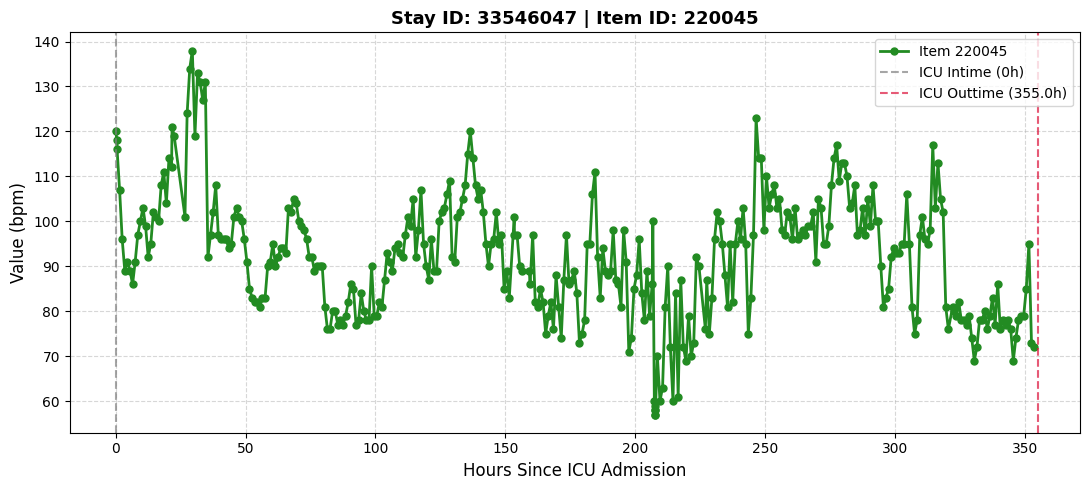

In [44]:
# Heart Rate
plot_icu_feature_by_intime(df_chart, key_id_icu, target_stay_id=33546047, target_itemid=220045, color='forestgreen')

In [45]:
# BNP
plot_icu_feature_by_intime(df_chart, key_id_icu, target_stay_id=33546047, target_itemid=227446, color='red')

⚠️ 데이터셋에서 stay_id: 33546047 / itemid: 227446 에 해당하는 기록이 없습니다.


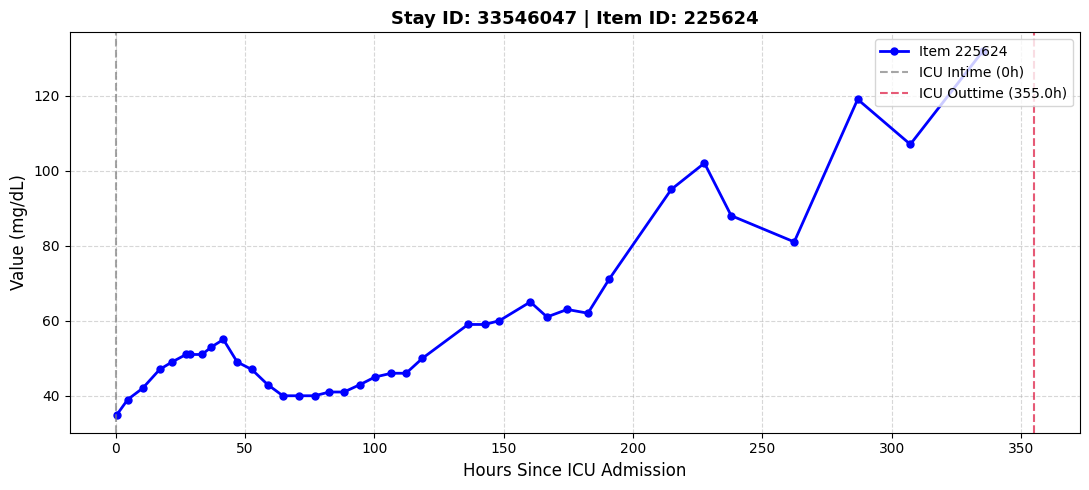

In [46]:
# BUN
plot_icu_feature_by_intime(df_chart, key_id_icu, target_stay_id=33546047, target_itemid=225624, color='blue')

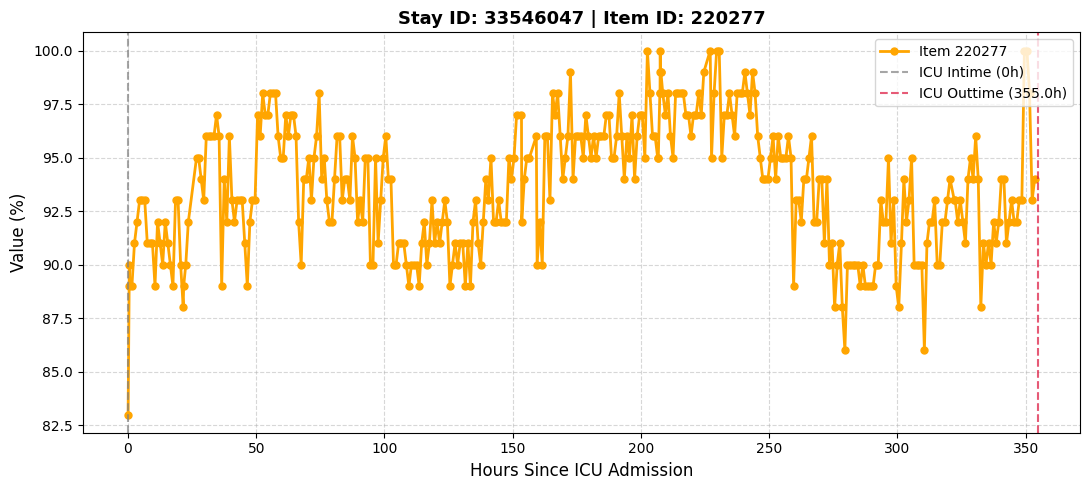

In [47]:
# spo2
plot_icu_feature_by_intime(df_chart, key_id_icu, target_stay_id=33546047, target_itemid=220277, color='orange')

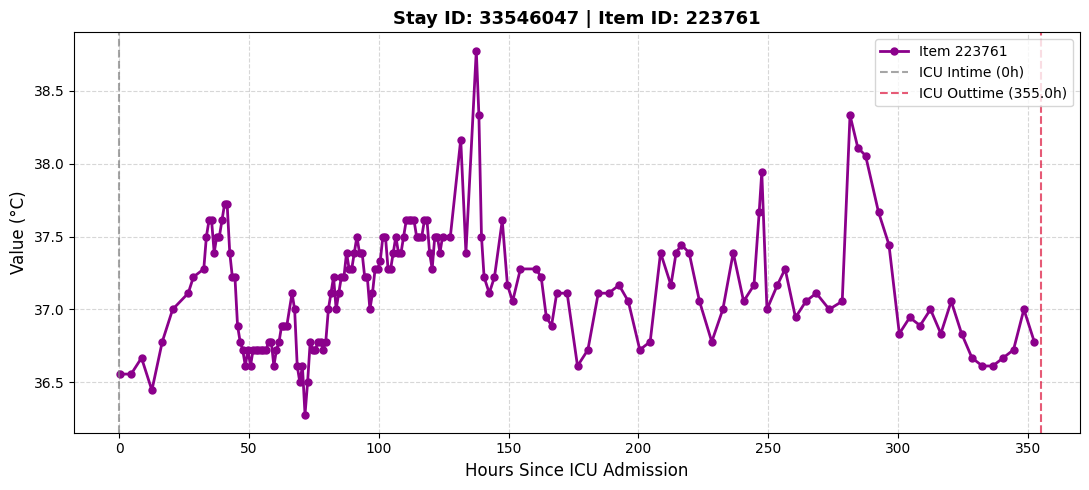

In [48]:
# temperature
plot_icu_feature_by_intime(df_chart, key_id_icu, target_stay_id=33546047, target_itemid=223761, color='darkmagenta')

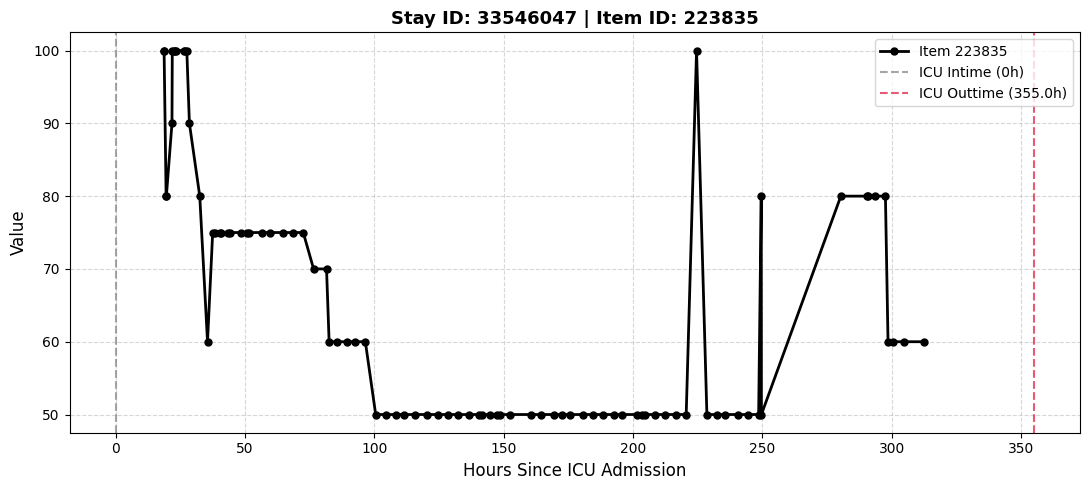

In [49]:
# Fio2
plot_icu_feature_by_intime(df_chart, key_id_icu, target_stay_id=33546047, target_itemid=223835, color='black')

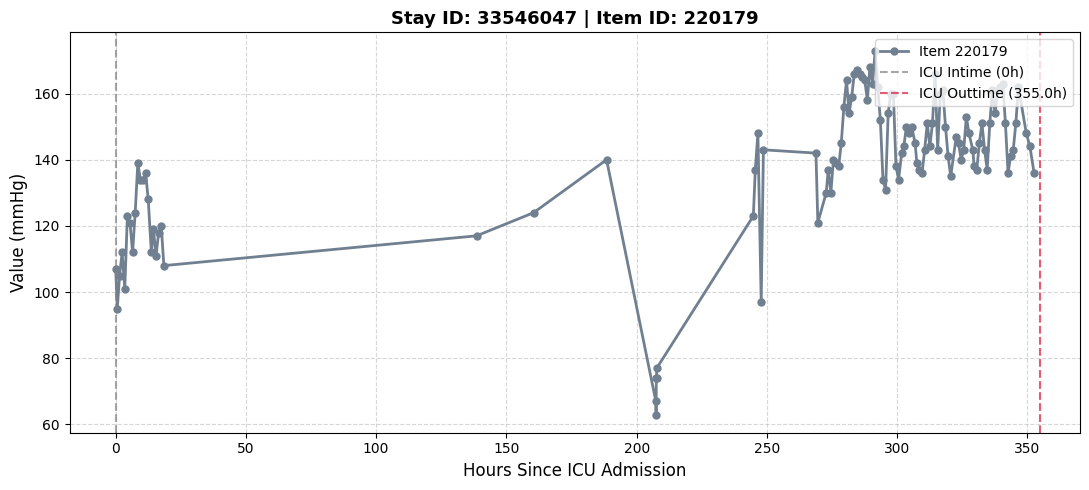

In [53]:
# ABPs/NBPs
plot_icu_feature_by_intime(df_chart, key_id_icu, target_stay_id=33546047, target_itemid=220179, color='slategrey')

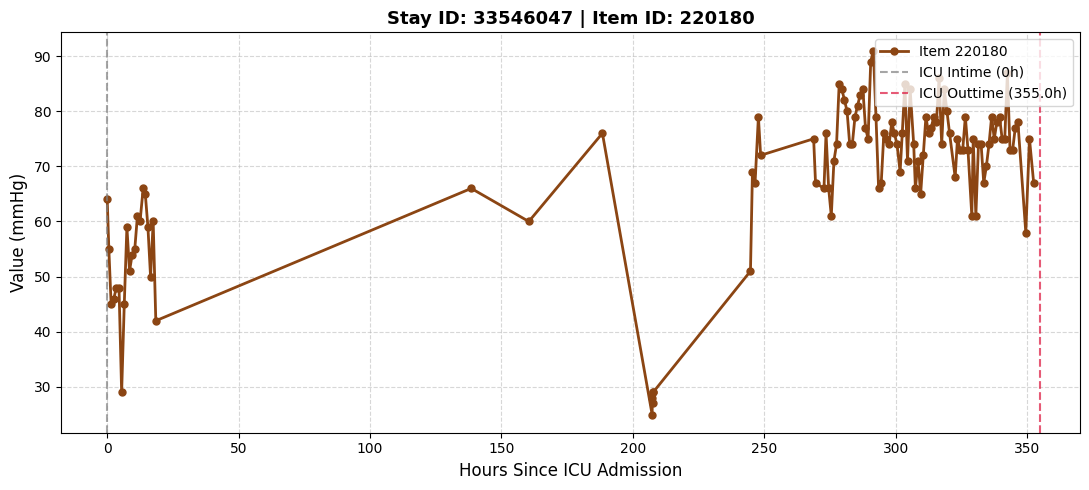

In [51]:
# ABPd/NBPd
plot_icu_feature_by_intime(df_chart, key_id_icu, target_stay_id=33546047, target_itemid=220180, color='saddlebrown')

In [299]:
df_chart[df_chart['itemid']==220179]

,subject_id,hadm_id,stay_id,charttime,itemid,value,valuenum,valueuom
4,10001884,26184834,37510196,2131-01-18 19:01:00,220179,122,122.0,mmHg
47,10001884,26184834,37510196,2131-01-18 20:01:00,220179,120,120.0,mmHg
53,10001884,26184834,37510196,2131-01-18 21:01:00,220179,137,137.0,mmHg
62,10001884,26184834,37510196,2131-01-18 22:01:00,220179,94,94.0,mmHg
67,10001884,26184834,37510196,2131-01-18 23:01:00,220179,117,117.0,mmHg
...,...,...,...,...,...,...,...,...
40344557,19999987,23865745,36195440,2145-11-03 04:00:00,220179,106,106.0,mmHg
40344583,19999987,23865745,36195440,2145-11-03 05:00:00,220179,113,113.0,mmHg
40344595,19999987,23865745,36195440,2145-11-03 06:00:00,220179,110,110.0,mmHg
40344649,19999987,23865745,36195440,2145-11-04 19:31:00,220179,163,163.0,mmHg


In [226]:
val_df[(val_df['p_cpe']>0.5) & (val_df['227446']>4000)]

,subject_id,hadm_id,stay_id,slot_idx,Edema,Edema_soft,subtype_label,subtype_mask,p_mixed,p_ncpe,p_cpe,220045,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,sbp,dbp,urine,cryst_weight
24924,10610928,20640912,33089935,125,1.0,1.0,2.0,1.0,0.151202,0.080932,0.767866,103.000000,28.0,89.000000,16.6,3.5,136.00,36.611111,0.40,38.0,1.0,18.0,0.05,4.300,4.0,32318.0,2.9,222.500000,166.0,97.0,2.149682,0.199401
53620,11360891,22429517,32354505,63,1.0,1.0,2.0,1.0,0.013911,0.010834,0.975255,84.000000,32.0,100.000000,17.9,2.1,131.00,36.200000,0.40,39.0,2.0,18.0,1.19,3.900,27.0,32015.0,3.9,250.000000,78.0,62.0,22.881356,1.590376
53765,11360891,22429517,32354505,208,1.0,1.0,2.0,1.0,0.008521,0.006636,0.984844,110.000000,15.0,96.000000,5.1,1.1,139.00,37.833333,0.40,38.0,1.5,16.0,1.18,4.100,27.0,32015.0,3.9,240.000000,86.0,54.0,53.389831,0.051676
53813,11360891,22429517,32354505,256,1.0,1.0,2.0,1.0,0.052240,0.021777,0.925983,111.000000,26.0,92.000000,6.4,1.4,145.00,38.444444,0.50,38.0,1.5,19.0,1.18,3.900,27.0,32015.0,3.9,184.000000,86.0,54.0,44.132602,0.051234
53861,11360891,22429517,32354505,304,1.0,1.0,2.0,1.0,0.008521,0.006636,0.984844,82.000000,23.0,99.000000,6.4,1.6,145.00,38.111111,0.40,47.0,1.5,14.0,1.18,4.000,27.0,32015.0,3.9,247.500000,86.0,54.0,16.386555,0.177755
64443,11673931,25054114,38364246,178,1.0,1.0,2.0,1.0,0.124130,0.066442,0.809428,133.000000,20.0,92.000000,27.1,1.0,138.00,36.777778,0.40,40.0,3.9,16.0,0.03,3.400,2.0,13056.0,3.1,230.000000,115.0,85.0,0.000000,0.494360
64511,11673931,25054114,38364246,246,1.0,1.0,2.0,1.0,0.040905,0.028113,0.930982,61.000000,16.0,100.000000,11.2,1.6,141.00,37.100000,0.40,43.0,1.2,17.0,0.11,3.500,3.0,13056.0,3.1,250.000000,96.0,62.0,50.847458,0.231367
64529,11673931,25054114,38364246,264,1.0,1.0,2.0,1.0,0.057974,0.035163,0.906863,62.000000,15.0,97.000000,13.0,1.8,138.00,36.800000,0.40,47.0,1.4,14.0,0.11,3.400,3.0,13056.0,2.3,242.500000,96.0,62.0,43.118644,0.129743
64561,11673931,25054114,38364246,296,1.0,1.0,2.0,1.0,0.057974,0.035163,0.906863,82.000000,15.0,99.000000,12.6,1.9,141.00,36.900000,0.40,50.0,0.8,17.0,0.10,2.900,2.0,13056.0,2.3,247.500000,96.0,62.0,114.406780,0.541278
64606,11673931,25054114,38364246,341,1.0,1.0,2.0,1.0,0.057974,0.035163,0.906863,73.000000,13.0,99.000000,15.7,1.9,144.00,36.888889,0.35,48.0,0.8,17.0,0.11,3.000,1.0,13056.0,2.3,282.857143,110.0,61.0,7.118644,0.082900


In [218]:
temp_df.iloc[80:120]

,subject_id,hadm_id,stay_id,slot_idx,Edema,Edema_soft,subtype_label,subtype_mask,p_mixed,p_ncpe,p_cpe,220045,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,sbp,dbp,urine,cryst_weight
80,11543398,29228250,31497701,80,NaN,0.340363,NaN,0.0,0.00000,0.000000,0.000000,110.0,24.0,94.0,7.8,3.9,143.0,36.777778,0.5,72.0,1.0,18.0,0.06,4.1,11.0,3972.0,3.0,188.0,159.0,132.0,27.285311,0.029231
81,11543398,29228250,31497701,81,NaN,0.391533,NaN,0.0,0.00000,0.000000,0.000000,110.0,24.0,94.0,7.8,3.9,143.0,36.777778,0.5,72.0,1.0,18.0,0.06,4.1,11.0,3972.0,3.0,188.0,159.0,132.0,25.423729,0.029231
82,11543398,29228250,31497701,82,NaN,0.445131,NaN,0.0,0.00000,0.000000,0.000000,124.0,24.0,93.0,7.8,3.9,143.0,36.777778,0.5,72.0,1.0,18.0,0.06,4.1,11.0,3972.0,3.0,186.0,124.0,83.0,30.091808,0.029231
83,11543398,29228250,31497701,83,NaN,0.500000,NaN,0.0,0.00000,0.000000,0.000000,124.0,24.0,93.0,7.8,3.9,143.0,36.777778,0.5,72.0,1.0,18.0,0.06,4.1,11.0,3972.0,3.0,186.0,124.0,83.0,38.135593,0.029231
84,11543398,29228250,31497701,84,NaN,0.554869,NaN,0.0,0.00000,0.000000,0.000000,95.0,22.0,96.0,7.8,3.9,143.0,36.777778,0.5,72.0,1.0,18.0,0.06,4.1,11.0,3972.0,3.0,192.0,138.0,58.0,37.967514,0.029231
85,11543398,29228250,31497701,85,NaN,0.608467,NaN,0.0,0.00000,0.000000,0.000000,95.0,22.0,96.0,7.8,3.9,143.0,36.777778,0.5,72.0,1.0,18.0,0.06,4.1,11.0,3972.0,3.0,192.0,138.0,58.0,40.677966,0.029231
86,11543398,29228250,31497701,86,NaN,0.659637,NaN,0.0,0.00000,0.000000,0.000000,91.0,23.0,97.0,7.8,3.9,143.0,36.722222,0.5,72.0,1.0,18.0,0.06,4.1,11.0,3972.0,3.0,194.0,138.0,58.0,43.734463,0.029231
87,11543398,29228250,31497701,87,NaN,0.707432,NaN,0.0,0.00000,0.000000,0.000000,91.0,23.0,97.0,7.8,3.9,143.0,36.722222,0.5,72.0,1.0,18.0,0.06,4.1,11.0,3972.0,3.0,194.0,138.0,58.0,50.847458,0.029231
88,11543398,29228250,31497701,88,NaN,0.751170,NaN,0.0,0.00000,0.000000,0.000000,84.0,21.0,96.0,7.8,3.9,143.0,36.722222,0.5,72.0,1.0,18.0,0.06,4.1,11.0,3972.0,3.0,192.0,133.0,58.0,42.533898,0.029231
89,11543398,29228250,31497701,89,NaN,0.790454,NaN,0.0,0.00000,0.000000,0.000000,84.0,21.0,96.0,7.8,3.9,143.0,36.722222,0.5,72.0,1.0,18.0,0.06,4.1,11.0,3972.0,3.0,192.0,133.0,58.0,35.593220,0.029231


In [196]:
print("\n" + "="*80)
print("Saving Processed Data")
print("="*80)

output_dir = '/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/'

train_final.to_feather(output_dir + 'train_multimodal_20260611.ftr')
print(f"✅ Saved: {output_dir}train_multimodal_20260611.ftr")

val_final.to_feather(output_dir + 'val_multimodal_20260611.ftr')
print(f"✅ Saved: {output_dir}val_multimodal_20260611.ftr")

test_final.to_feather(output_dir + 'test_multimodal_20260611.ftr')
print(f"✅ Saved: {output_dir}test_multimodal_20260611.ftr")

# save_scaling_stats(scaling_stats, output_dir + 'scaling_stats_20260513.pkl')

print("\n" + "="*80)
print("✅ ALL PREPROCESSING COMPLETED!")
print("="*80)
print("\n📊 Data Summary:")
print(f"  Train: {len(train_final):,} rows from {train_final['subject_id'].nunique():,} Patients / {train_final['stay_id'].nunique():,} ICU Stay Record")
print(f"  Val:   {len(val_final):,} rows from {val_final['subject_id'].nunique():,} Patients / {val_final['stay_id'].nunique():,} ICU Stay Record")
print(f"  Test:  {len(test_final):,} rows from {test_final['subject_id'].nunique():,} Patients / {test_final['stay_id'].nunique():,} ICU Stay Record")
print(f"\n  Total columns: {len(train_final.columns)}")
print(f"  Feature columns (with flags): {len([c for c in train_final.columns if '_flag' in c or c not in meta_cols])}")



Saving Processed Data
✅ Saved: /home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/train_multimodal_20260611.ftr
✅ Saved: /home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/val_multimodal_20260611.ftr
✅ Saved: /home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/test_multimodal_20260611.ftr

✅ ALL PREPROCESSING COMPLETED!

📊 Data Summary:
  Train: 1,703,251 rows from 7,334 Patients / 9,450 ICU Stay Record
  Val:   354,938 rows from 1,572 Patients / 2,021 ICU Stay Record
  Test:  359,960 rows from 1,572 Patients / 1,967 ICU Stay Record

  Total columns: 37
  Feature columns (with flags): 26


In [197]:
train_final[train_final['text_embed_path'].notnull()]

,subject_id,hadm_id,stay_id,slot_idx,Edema,Edema_soft,subtype_label,subtype_mask,p_mixed,p_ncpe,p_cpe,220045,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,sbp,dbp,urine,cryst_weight,cxr_flag,raddino_emb_path,hybrid_emb_path,text_embed_path,text_flag
4,10002428,23473524,35479615,4,0.0,0.0,NaN,0.0,0.0,0.0,0.0,67.5,18.0,100.0,10.5,1.0,138.0,36.888889,0.40,22.0,1.4,14.0,0.05,4.0,4.0,3972.0,3.0,250.000000,115.0,62.0,44.788853,4.414891,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0
7,10002428,23473524,35479615,7,0.0,0.0,NaN,0.0,0.0,0.0,0.0,73.0,18.0,100.0,10.5,1.0,138.0,36.222222,0.40,22.0,1.5,14.0,0.05,4.0,4.0,3972.0,3.0,250.000000,115.0,62.0,10.000000,0.097993,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0
26,10002428,23473524,35479615,26,0.0,0.0,NaN,0.0,0.0,0.0,0.0,92.0,20.0,98.0,11.0,0.4,135.0,37.833333,0.40,12.0,0.7,8.0,0.05,3.1,6.0,3972.0,3.0,245.000000,115.0,62.0,119.867232,0.244990,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0
75,10002428,23473524,35479615,75,0.0,0.0,NaN,0.0,0.0,0.0,0.0,98.0,19.0,99.0,7.4,0.3,139.0,37.166667,0.40,8.0,0.5,7.0,0.05,3.3,6.0,3972.0,2.2,247.500000,112.0,65.0,25.210084,0.080341,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0
179,10002428,23473524,35479615,179,0.0,0.0,NaN,0.0,0.0,0.0,0.0,90.0,17.0,99.0,5.9,0.3,138.0,37.166667,0.30,6.0,0.5,7.0,0.05,3.6,6.0,3972.0,2.2,330.000000,112.0,62.0,37.218045,0.031342,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1702999,19998843,24842066,30988867,135,0.0,0.0,NaN,0.0,0.0,0.0,0.0,88.0,20.0,100.0,9.4,1.0,146.0,37.700000,0.35,8.0,1.3,9.0,0.05,3.9,4.0,3972.0,2.3,285.714286,115.0,62.0,67.457627,0.857423,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0
1703083,19999287,20175828,35165301,58,0.0,0.0,NaN,0.0,0.0,0.0,0.0,103.0,36.0,82.0,10.5,0.8,141.0,36.722222,0.40,12.0,1.4,14.0,0.01,3.8,3.0,3972.0,3.0,205.000000,141.0,65.0,14.376997,0.028809,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0
1703092,19999287,20175828,35165301,67,0.0,0.0,NaN,0.0,0.0,0.0,0.0,88.0,22.0,91.0,10.5,0.8,141.0,36.777778,0.70,12.0,1.4,14.0,0.01,3.8,3.0,3972.0,3.0,130.000000,113.0,50.0,14.376997,0.028809,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0
1703187,19999287,20175828,35165301,162,0.0,0.0,NaN,0.0,0.0,0.0,0.0,88.0,16.0,100.0,12.4,0.6,140.0,37.166667,0.50,9.0,0.8,12.0,0.01,4.3,3.0,3972.0,3.0,200.000000,123.0,60.0,10.084034,0.028785,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0


In [59]:
a = train_final[train_final['stay_id']==31497701].reset_index(drop=True)
a[a['text_embed_path'].notnull()]

,subject_id,hadm_id,stay_id,slot_idx,Cardiomegaly,Consolidation,Pneumonia,Edema,Edema_soft,220045,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,sbp,dbp,urine,cryst_weight,cxr_flag,raddino_emb_path,hybrid_emb_path,text_embed_path,text_flag,Edema_diff
2,11543398,29228250,31497701,2,0.0,0.0,0.0,0.0,0.0,84.5,21.0,98.5,8.6,5.9,140.0,37.555556,0.40,88.0,1.0,20.0,0.06,3.5,11.0,3972.0,3.0,246.250000,107.0,61.0,23.903475,0.000000,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0,NaN
60,11543398,29228250,31497701,60,1.0,1.0,0.0,0.0,0.0,88.0,23.0,95.0,7.4,4.8,142.0,36.888889,0.40,78.0,1.0,19.0,0.06,4.2,11.0,3972.0,3.0,237.500000,136.0,62.0,34.252825,0.029235,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0,NaN
106,11543398,29228250,31497701,106,0.0,0.0,0.0,1.0,1.0,91.0,28.0,93.0,7.7,3.4,145.0,37.055556,0.50,64.0,1.0,19.0,0.06,4.2,11.0,3972.0,3.0,186.000000,160.0,77.0,32.954802,0.029235,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0,NaN
151,11543398,29228250,31497701,151,1.0,0.0,0.0,1.0,1.0,87.0,31.0,94.0,9.7,2.4,150.0,37.055556,0.50,51.0,0.8,18.0,0.06,3.8,11.0,3972.0,3.0,188.000000,162.0,107.0,88.235294,0.029235,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0,NaN
152,11543398,29228250,31497701,152,0.0,0.0,0.0,0.0,0.0,89.0,16.0,96.0,9.7,2.4,150.0,37.055556,1.00,51.0,0.8,18.0,0.06,3.8,11.0,3972.0,3.0,96.000000,175.0,106.0,102.165171,0.029235,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0,-1.0
161,11543398,29228250,31497701,161,0.0,0.0,0.0,0.0,0.0,58.0,16.0,96.0,9.7,2.4,150.0,37.055556,0.60,51.0,1.1,18.0,0.06,3.8,11.0,3972.0,3.0,160.000000,112.0,49.0,63.025210,0.164203,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0,NaN
239,11543398,29228250,31497701,239,1.0,0.0,0.0,1.0,1.0,63.0,18.0,93.0,11.8,2.0,144.0,37.555556,0.50,45.0,0.9,14.0,0.06,3.5,11.0,3972.0,3.0,186.000000,109.0,39.0,111.864407,0.063932,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0,NaN
291,11543398,29228250,31497701,291,1.0,0.0,0.0,1.0,1.0,69.0,24.0,95.0,13.1,2.1,143.0,38.055556,0.55,49.0,1.1,17.0,0.06,3.8,11.0,3972.0,3.0,172.727273,134.0,49.0,26.470588,0.292190,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0,NaN
348,11543398,29228250,31497701,348,1.0,0.0,0.0,1.0,1.0,80.0,22.0,96.0,11.5,2.2,146.0,36.388889,0.40,58.0,1.1,17.0,0.06,3.6,11.0,3972.0,3.0,240.000000,146.0,72.0,50.420168,0.029234,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0,NaN
361,11543398,29228250,31497701,361,1.0,0.0,0.0,1.0,1.0,84.0,32.0,97.0,11.5,2.0,150.0,36.388889,0.40,59.0,1.1,16.0,0.06,4.6,11.0,3972.0,3.0,242.500000,157.0,64.0,165.254237,0.029234,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0,NaN


In [60]:
a.iloc[60:110]

,subject_id,hadm_id,stay_id,slot_idx,Cardiomegaly,Consolidation,Pneumonia,Edema,Edema_soft,220045,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,sbp,dbp,urine,cryst_weight,cxr_flag,raddino_emb_path,hybrid_emb_path,text_embed_path,text_flag,Edema_diff
60,11543398,29228250,31497701,60,1.0,1.0,0.0,0.0,0.000000,88.0,23.0,95.0,7.4,4.8,142.0,36.888889,0.4,78.0,1.0,19.0,0.06,4.2,11.0,3972.0,3.0,237.5,136.0,62.0,34.252825,0.029235,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0,NaN
61,11543398,29228250,31497701,61,NaN,NaN,NaN,NaN,0.001634,88.0,23.0,95.0,7.4,4.8,142.0,36.888889,0.4,78.0,1.0,19.0,0.06,4.2,11.0,3972.0,3.0,237.5,136.0,62.0,50.847458,0.029235,NaN,NaN,NaN,NaN,0.0,NaN
62,11543398,29228250,31497701,62,NaN,NaN,NaN,NaN,0.003657,80.0,22.0,96.0,7.4,4.8,142.0,37.388889,0.4,78.0,1.0,19.0,0.06,4.2,11.0,3972.0,3.0,240.0,115.0,58.0,43.637006,0.029235,NaN,NaN,NaN,NaN,0.0,NaN
63,11543398,29228250,31497701,63,NaN,NaN,NaN,NaN,0.006159,80.0,22.0,96.0,7.4,4.8,142.0,37.388889,0.4,78.0,1.0,19.0,0.06,4.2,11.0,3972.0,3.0,240.0,115.0,58.0,38.135593,2.368065,NaN,NaN,NaN,NaN,0.0,NaN
64,11543398,29228250,31497701,64,NaN,NaN,NaN,NaN,0.009253,74.0,22.0,96.0,7.4,4.8,142.0,37.388889,0.4,78.0,1.0,19.0,0.06,4.2,11.0,3972.0,3.0,240.0,122.0,58.0,36.864407,0.029235,NaN,NaN,NaN,NaN,0.0,NaN
65,11543398,29228250,31497701,65,NaN,NaN,NaN,NaN,0.013070,74.0,22.0,96.0,7.4,4.8,142.0,37.388889,0.4,78.0,1.0,19.0,0.06,4.2,11.0,3972.0,3.0,240.0,122.0,58.0,38.135593,0.029235,NaN,NaN,NaN,NaN,0.0,NaN
66,11543398,29228250,31497701,66,NaN,NaN,NaN,NaN,0.017775,80.0,17.0,95.0,7.4,4.8,142.0,37.388889,0.4,78.0,1.0,19.0,0.06,4.2,11.0,3972.0,3.0,237.5,127.0,92.0,39.459953,0.029235,NaN,NaN,NaN,NaN,0.0,NaN
67,11543398,29228250,31497701,67,NaN,NaN,NaN,NaN,0.023560,80.0,17.0,95.0,7.4,4.8,142.0,37.388889,0.4,78.0,1.0,19.0,0.06,4.2,11.0,3972.0,3.0,237.5,127.0,92.0,44.117647,0.029235,NaN,NaN,NaN,NaN,0.0,NaN
68,11543398,29228250,31497701,68,NaN,NaN,NaN,NaN,0.030656,83.0,24.0,93.0,7.4,4.8,142.0,37.388889,0.4,78.0,1.0,19.0,0.06,4.2,11.0,3972.0,3.0,232.5,111.0,74.0,44.117647,0.029235,NaN,NaN,NaN,NaN,0.0,NaN
69,11543398,29228250,31497701,69,NaN,NaN,NaN,NaN,0.039334,83.0,24.0,93.0,7.4,4.8,142.0,37.388889,0.4,78.0,1.0,19.0,0.06,4.2,11.0,3972.0,3.0,232.5,111.0,74.0,44.117647,0.029235,NaN,NaN,NaN,NaN,0.0,NaN


In [51]:
temp_path = '/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/pubmed_text_ids/stay_31497701_hour_106.pt'

data = torch.load(temp_path, map_location='cpu')

print("데이터 타입:", type(data))
print("포함된 Keys:", data.keys())
print("-" * 40)

print("input_ids shape:", data['input_ids'].shape)
print("input_ids dtype:", data['input_ids'].dtype)
print("attention_mask shape:", data['attention_mask'].shape)
print("-" * 40)

print("input_ids 샘플:\n", data['input_ids'])
print("attention_mask 샘플:\n", data['attention_mask'])

print("input_ids 샘플:\n", data['input_ids'])
print("attention_mask 샘플:\n", data['attention_mask'])
print("-" * 40)

# 4. 저장된 토큰 ID를 실제 텍스트 원문으로 복원하여 출력
# 텐서 형태가 [128] 일 것이므로 바로 디코딩이 가능합니다.
input_ids = data['input_ids']

print("--- [추가] 텍스트 복원 결과 확인 ---")
# [CLS], [SEP], [PAD] 같은 특수 토큰을 모두 포함해서 어떻게 패딩되었는지 확인
full_text = pubmed_tokenizer.decode(input_ids)
print("1. 전체 복원 (특수 토큰 포함):\n", full_text)
print("-" * 40)

# 원래의 순수한 텍스트 내용만 확인
clean_text = pubmed_tokenizer.decode(input_ids, skip_special_tokens=True)
print("2. 순수 텍스트 복원 (skip_special_tokens=True):\n", clean_text)

데이터 타입: <class 'dict'>
포함된 Keys: dict_keys(['input_ids', 'attention_mask'])
----------------------------------------
input_ids shape: torch.Size([128])
input_ids dtype: torch.int64
attention_mask shape: torch.Size([128])
----------------------------------------
input_ids 샘플:
 tensor([    2,  1922,  3723,  1956,  1920,  2161,  1927,    41,    41,    41,
           16,  1920, 21129,  5476, 13845,  1923,  4059, 15492,  6488,  1977,
        10163,  9913,    18,  7583,  5352,  4541, 24053,  1956,  7787, 17673,
         1036,  1930, 18978, 30395, 30280, 25419,  3857,  8362, 19092,    18,
            3,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,

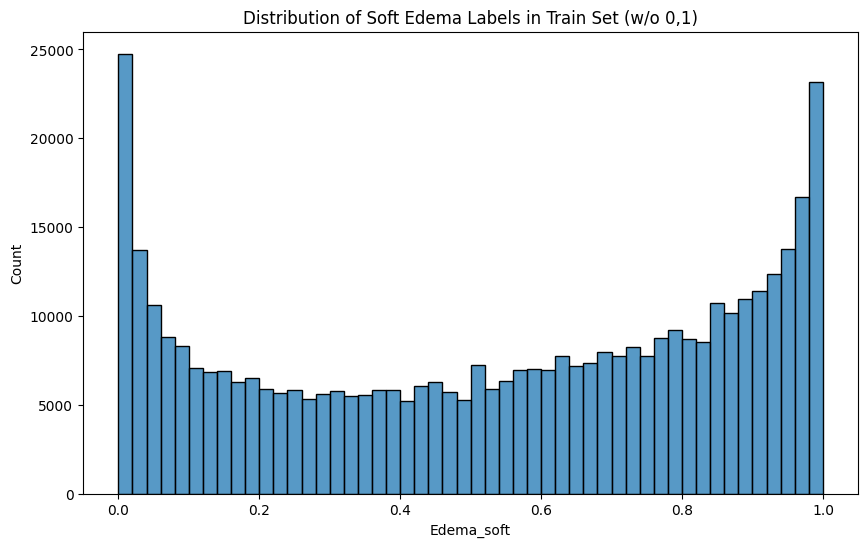

In [35]:
filtered_data = train_final[(train_final['Edema_soft'] != 0) & (train_final['Edema_soft'] != 1)]['Edema_soft']

plt.figure(figsize=(10, 6))
sns.histplot(filtered_data, bins=50)
plt.title('Distribution of Soft Edema Labels in Train Set (w/o 0,1)')
plt.show()

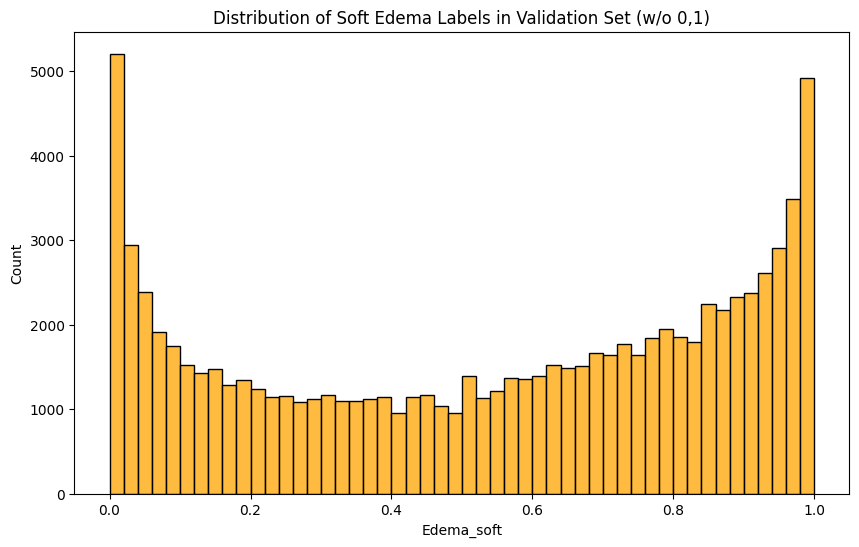

In [110]:
filtered_data = val_final[(val_final['Edema_soft'] != 0) & (val_final['Edema_soft'] != 1)]['Edema_soft']

plt.figure(figsize=(10, 6))
sns.histplot(filtered_data, bins=50, color='orange')
plt.title('Distribution of Soft Edema Labels in Validation Set (w/o 0,1)')
plt.show()

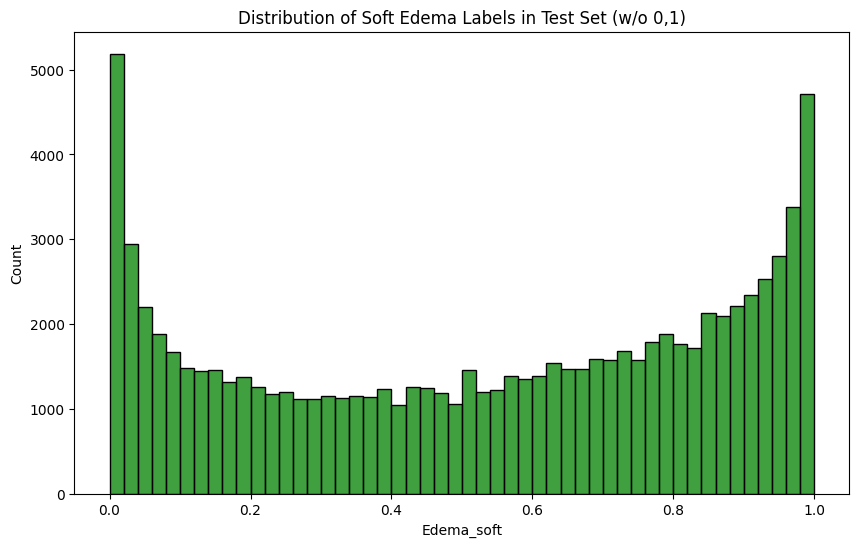

In [111]:
filtered_data = test_final[(test_final['Edema_soft'] != 0) & (test_final['Edema_soft'] != 1)]['Edema_soft']

plt.figure(figsize=(10, 6))
sns.histplot(filtered_data, bins=50, color='green')
plt.title('Distribution of Soft Edema Labels in Test Set (w/o 0,1)')
plt.show()

In [112]:
len(train_final.columns)

35

In [113]:
print(f"학습 데이터에서 Edema soft label이 부여된 행수: {len(train_final[train_final['Edema_soft'] > 0])}")

학습 데이터에서 Edema soft label이 부여된 행수: 641205


In [114]:
train_final

,subject_id,hadm_id,stay_id,slot_idx,Cardiomegaly,Consolidation,Pneumonia,Edema,Edema_soft,220045,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,sbp,dbp,urine,cryst_weight,cxr_flag,raddino_emb_path,hybrid_emb_path,text_embed_path,text_flag
0,10002428,23473524,35479615,0,NaN,NaN,NaN,NaN,0.0,86.0,20.0,97.0,10.5,1.0,138.0,36.888889,0.4,22.0,1.4,14.0,0.05,4.0,4.0,3972.0,3.0,242.5,115.0,62.0,44.788853,0.000000,NaN,NaN,NaN,NaN,0.0
1,10002428,23473524,35479615,1,NaN,NaN,NaN,NaN,0.0,86.0,20.0,97.0,10.5,1.0,138.0,36.888889,0.4,22.0,1.4,14.0,0.05,4.0,4.0,3972.0,3.0,242.5,115.0,62.0,44.788853,0.000000,NaN,NaN,NaN,NaN,0.0
2,10002428,23473524,35479615,2,NaN,NaN,NaN,NaN,0.0,67.5,17.5,100.0,10.5,1.0,138.0,36.888889,0.4,22.0,1.4,14.0,0.05,4.0,4.0,3972.0,3.0,250.0,115.0,62.0,44.788853,0.000000,NaN,NaN,NaN,NaN,0.0
3,10002428,23473524,35479615,3,NaN,NaN,NaN,NaN,0.0,69.5,18.0,100.0,10.5,1.0,138.0,36.888889,0.4,22.0,1.4,14.0,0.05,4.0,4.0,3972.0,3.0,250.0,115.0,62.0,44.788853,0.063897,NaN,NaN,NaN,NaN,0.0
4,10002428,23473524,35479615,4,0.0,0.0,0.0,0.0,0.0,67.5,18.0,100.0,10.5,1.0,138.0,36.888889,0.4,22.0,1.4,14.0,0.05,4.0,4.0,3972.0,3.0,250.0,115.0,62.0,44.788853,4.413807,1.0,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1703246,19999287,20175828,35165301,221,NaN,NaN,NaN,NaN,0.0,80.0,16.0,97.0,10.9,0.7,141.0,36.888889,0.5,14.0,0.8,13.0,0.01,3.9,3.0,3972.0,3.0,194.0,113.0,44.0,20.779221,0.000000,NaN,NaN,NaN,NaN,0.0
1703247,19999287,20175828,35165301,222,NaN,NaN,NaN,NaN,0.0,80.0,16.0,97.0,10.9,0.7,141.0,36.888889,0.5,14.0,0.8,13.0,0.01,3.9,3.0,3972.0,3.0,194.0,113.0,44.0,0.000000,0.000000,NaN,NaN,NaN,NaN,0.0
1703248,19999287,20175828,35165301,223,NaN,NaN,NaN,NaN,NaN,97.0,16.0,94.0,10.9,0.7,141.0,36.888889,0.5,14.0,0.8,13.0,0.01,3.9,3.0,3972.0,3.0,188.0,126.0,76.0,0.000000,0.000000,NaN,NaN,NaN,NaN,0.0
1703249,19999287,20175828,35165301,224,NaN,NaN,NaN,NaN,NaN,97.0,16.0,94.0,10.9,0.7,141.0,36.888889,0.5,14.0,0.8,13.0,0.01,3.9,3.0,3972.0,3.0,188.0,126.0,76.0,0.000000,0.000000,NaN,NaN,NaN,NaN,0.0
